![alt text](./Cerny_logo_1.jpg)

# Analysis of Cerny ventilation recordings

## Further processing of HFOV data for cases `AT000001-AT001251`

This Notebook produces Excel statistics about ventilator parameters in cases ventilated with HFOV. It also exports barplots showing statistics on ventilation modes used. It does not produse graphs on individual recordings . 

### 1. Import the necessary libraries and set options

In [1]:
import IPython
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as dates

import os
import sys
import pickle

from pandas import Series, DataFrame
from datetime import datetime, timedelta

%matplotlib inline
matplotlib.style.use('classic')
matplotlib.rcParams['figure.facecolor'] = 'w'

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 300)
pd.set_option('mode.chained_assignment', None)

# Percentiles for the describe() function
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

In [2]:
print("Python version: {}".format(sys.version))
print("pandas version: {}".format(pd.__version__))
print("matplotlib version: {}".format(matplotlib.__version__))
print("NumPy version: {}".format(np.__version__))
print("IPython version: {}".format(IPython.__version__))

Python version: 3.11.7 (main, Dec 15 2023, 12:09:04) [Clang 14.0.6 ]
pandas version: 2.1.4
matplotlib version: 3.8.0
NumPy version: 1.26.3
IPython version: 8.20.0


In [3]:
# Define styling of boxplots
medianprops = {'color':'black', 'linewidth':2}; boxprops = {'color':'black', 'linestyle':'-'}
whiskerprops = {'color':'black', 'linestyle':'-'}; capprops = {'color':'black', 'linestyle':'-'}
flierprops = {'color':'black', 'marker': '.'}
meanprops =  {'marker':'D', 'markeredgecolor':'black', 'markerfacecolor':'white'}

### 2. List and set the working directory and the directory to write out data

In [4]:
# Topic of the Notebook which will also be the name of the subfolder containing results
TOPIC = 'HFOV'

# Path to project folder containing clinical data (current weights only) and for export of results
PATH = os.path.join(os.sep, 'Users', 'guszti', 'Library', 'Mobile Documents', 'com~apple~CloudDocs', 
                            'Documents', 'Research', 'Ventilation')

# Name of the external hard drive
DRIVE = 'GUSZTI'

# Folder containing the file with the manually collected clinical data
DIR_READ_CLIN = os.path.join(os.sep, PATH, 'ventilation_fabian_new')

# Processed data loaded from external drive
DIR_READ = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_new')

# Results will be written in this folder
DIR_WRITE =  os.path.join(os.sep, PATH, 'ventilation_fabian_new', 'Analyses', TOPIC)
os.makedirs(DIR_WRITE, exist_ok=True)

# Images and raw data will be written on an external hard drive
DATA_DUMP = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_new', TOPIC)
os.makedirs(DATA_DUMP, exist_ok=True)

In [5]:
DIR_READ_CLIN, DIR_READ, DIR_WRITE, DATA_DUMP,

('/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new',
 '/Volumes/GUSZTI/data_dump/fabian_new',
 '/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new/Analyses/HFOV',
 '/Volumes/GUSZTI/data_dump/fabian_new/HFOV')

### 3. Import processed data

#### A. Import ventilator data from pickle archives

In [6]:
## Import into pickle archives containing data as dictionaries DataFrames

# All recordings included in the final analysis, both HFOV and conventional ventilation data
with open(os.path.join(DATA_DUMP, 'data_pars_hfov.pickle'), 'rb') as handle:
    data_pars_hfov = pickle.load(handle)

# All recordings included in the final analysis, only HFOV parts    
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_only.pickle'), 'rb') as handle:
    data_pars_hfov_only = pickle.load(handle)

# Only recordings selected as HFOV-VG and only HFOV-VG parts
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_vg_only.pickle'), 'rb') as handle:
    data_pars_hfov_vg_only = pickle.load(handle)

# Only recordings selected as HFOV-noVG and only HFOV-noVG parts
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_novg_only.pickle'), 'rb') as handle:
    data_pars_hfov_novg_only = pickle.load(handle)

# Only recordings selected as containing >10% of both HFOV-VG and HFOV-noVG, and only HFOV parts
with open(os.path.join(DATA_DUMP, 'data_pars_both_hfov_vg_novg.pickle'), 'rb') as handle:
    data_pars_both_hfov_vg_novg = pickle.load(handle)


## Import into pickle archive as combined in a single Dataframe

# All recordings included in the final analysis, both HFOV and conventional ventilation data
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_combined.pickle'), 'rb') as handle:
    data_pars_hfov_combined = pickle.load(handle)

# All recordings included in the final analysis, only HFOV parts    
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_only_combined.pickle'), 'rb') as handle:
    data_pars_hfov_only_combined = pickle.load(handle)

# Only recordings selected as HFOV-VG and only HFOV-VG parts
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_vg_only_combined.pickle'), 'rb') as handle:
    data_pars_hfov_vg_only_combined = pickle.load(handle)

# Only recordings selected as HFOV-noVG and only HFOV-noVG parts
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_novg_only_combined.pickle'), 'rb') as handle:
    data_pars_hfov_novg_only_combined = pickle.load(handle)

# Only recordings selected as containing >10% of both HFOV-VG and HFOV-noVG, and only HFOV parts
with open(os.path.join(DATA_DUMP, 'data_pars_both_hfov_vg_novg_combined.pickle'), 'rb') as handle:
    data_pars_both_hfov_vg_novg_combined = pickle.load(handle)

In [7]:
[len(data_pars_hfov), len(data_pars_hfov_only), len(data_pars_hfov_vg_only), len(data_pars_hfov_novg_only), 
 len(data_pars_both_hfov_vg_novg)]

[51, 51, 26, 22, 3]

In [8]:
[len(data_pars_hfov_combined), len(data_pars_hfov_only_combined), len(data_pars_hfov_vg_only_combined), 
 len(data_pars_hfov_novg_only_combined), len(data_pars_both_hfov_vg_novg_combined)]

[89132, 80961, 42108, 33157, 5063]

#### B. Import computationally blood gases

In [9]:
with open(os.path.join(DIR_READ, 'blood_gases_new.pickle'), 'rb') as handle:
    blood_gases_automatic = pickle.load(handle)
blood_gases_hfov = {key:value for key,value in blood_gases_automatic.items() if key in data_pars_hfov.keys()}
len(blood_gases_hfov)

50

### 4. Analyse ventilator parameters in all HFOV recordings (including both the conventional and HFOV parts)

Only **FiO2**, **MAP** and **Leak** are meaningful parameters across both conventional and HFOV ventilation

In [10]:
pars_for_stats = ['FiO2', 'MAP', 'Leak', 'Flow_insp_set']
# Parameters showing approximately normal distribution within the individual recordings

#### A. In all recordings together

The problem with this that the various recording are of different length and therefore it is a skewed dataset

In [11]:
stats_hfov_plus_conv_combined = round(data_pars_hfov_combined[pars_for_stats].describe(percentiles=percentiles), 1)
stats_hfov_plus_conv_combined

,FiO2,MAP,Leak,Flow_insp_set
count,89132.0,89132.0,89131.0,89132.0
mean,79.0,14.0,2.5,11.0
std,24.6,3.7,7.7,2.7
min,20.0,0.0,0.0,7.0
1%,20.3,0.0,0.0,7.0
5%,24.9,9.3,0.0,9.0
25%,65.2,11.9,0.0,10.0
50%,90.8,13.8,0.0,10.0
75%,97.9,16.5,0.0,11.0
95%,99.5,19.8,15.0,20.0


#### B. In the individual recordings

MAP distribution is parametric, FiO2 and leak are non-parametric

In [12]:
pars_for_mean = ['MAP']
# Parameters not showing normal distribution within the individual recordings
pars_for_median = ['FiO2', 'Leak', 'Flow_insp_set']

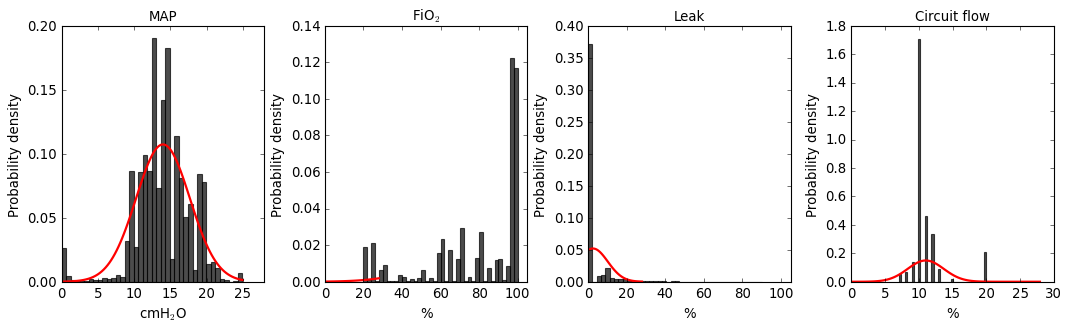

In [13]:
filetype = 'jpg'; dpi = 200

fig, ax = plt.subplots(1,4, figsize = [16, 4])
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.4)
ax = ax.ravel()

data = data_pars_hfov_combined['MAP']
ax[0].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[0].plot(x, p, linewidth=2, color = 'red')
ax[0].set_xlabel('cmH$_2$O', size = 12)
ax[0].set_ylabel('Probability density', size = 12)
ax[0].set_xlim(0, data.mean()*2)
ax[0].set_title('MAP', fontsize = 12)

data = data_pars_hfov_combined['FiO2']
ax[1].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[1].plot(x, p, linewidth=2, color = 'red')
ax[1].set_xlabel('%', size = 12)
ax[1].set_ylabel('Probability density', size = 12)
ax[1].set_xlim(0, 105)
ax[1].set_title('FiO$_2$', fontsize = 12)

data = data_pars_hfov_combined['Leak']
ax[2].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[2].plot(x, p, linewidth=2, color = 'red')
ax[2].set_xlabel('%', size = 12)
ax[2].set_ylabel('Probability density', size = 12)
ax[2].set_xlim(0, 105)
ax[2].set_title('Leak', fontsize = 12)

data = data_pars_hfov_combined['Flow_insp_set']
ax[3].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[3].plot(x, p, linewidth=2, color = 'red')
ax[3].set_xlabel('%', size = 12)
ax[3].set_ylabel('Probability density', size = 12)
ax[3].set_xlim(0, 30)
ax[3].set_title('Circuit flow', fontsize = 12)

fig.savefig(os.path.join(DIR_WRITE, f'hfov_plus_conv_MAP_FiO2_Leak_Circuit_flow_with_pdf.{filetype}'), dpi = dpi, 
            format = filetype, bbox_inches='tight')

In [14]:
# Stats in the individual recordings
stats_hfov_plus_conv = round(data_pars_hfov_combined.groupby(level=0)[pars_for_stats].describe(), 1)
stats_hfov_plus_conv.head()

FiO2                                               MAP             \
           count  mean   std   min   25%   50%   75%   max   count  mean  std   
case                                                                            
AT000033  1215.0  96.9   1.3  77.3  96.3  96.9  97.8  98.3  1215.0  14.7  0.6   
AT000034   827.0  97.5   0.8  94.4  96.7  97.4  98.2  98.6   827.0  15.2  0.5   
AT000048  1422.0  97.8   1.6  73.6  96.6  98.4  98.8  99.1  1422.0  15.6  0.5   
AT000086  1021.0  82.8   8.1  69.4  75.2  80.8  89.3  97.7  1021.0  10.5  0.3   
AT000122  1170.0  78.7  12.5  60.4  69.8  80.0  89.7  97.7  1170.0  13.0  0.7   

                                          Leak                             \
           min   25%   50%   75%   max   count  mean  std  min  25%   50%   
case                                                                        
AT000033   0.0  14.7  14.7  14.7  16.0  1215.0   0.1  1.6  0.0  0.0   0.0   
AT000034  14.5  14.7  15.6  15.7  15.7   827.0   0.3  4.6  0.0  0.0   0.0   
AT000048   9.2  15.6  15.6  15.7  15.8  1422.0   0.5  5.4  0.0  0.0   0.0   
AT000086   4.5  10.5  10.5  10.6  11.3  1021.0  10.2  5.5  0.0  8.0  12.0   
AT000122   0.0  13.0  13.0  13.1  18.5  1170.0   0.1  2.7  0.0  0.0   0.0   

                     Flow_insp_set                                           
           75%   max         count  mean  std   min   25%   50%   75%   max  
case                                                                         
AT000033   0.0  34.0        1215.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0  
AT000034   0.0  86.0         827.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0  
AT000048   0.0  65.0        1422.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0  
AT000086  14.0  21.0        1021.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0  
AT000122   0.0  68.0        1170.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0

In [15]:
# Group stats
group_stats_hfov_plus_conv_mean = round(stats_hfov_plus_conv.swaplevel(axis=1)['mean'][pars_for_mean].describe(percentiles = percentiles), 1)
group_stats_hfov_plus_conv_mean.rename(lambda x:f'{x}_mean', axis=1, inplace=True)
group_stats_hfov_plus_conv_mean

,MAP_mean
count,51.0
mean,13.7
std,2.3
min,9.4
1%,9.4
5%,10.5
25%,12.1
50%,13.7
75%,15.2
95%,17.4


In [16]:
# Group stats
group_stats_hfov_plus_conv_median = round(stats_hfov_plus_conv.swaplevel(axis=1)['50%'][pars_for_median].describe(percentiles = percentiles), 1)
group_stats_hfov_plus_conv_median.rename(lambda x:f'{x}_median', axis=1, inplace=True)
group_stats_hfov_plus_conv_median

,FiO2_median,Leak_median,Flow_insp_set_median
count,51.0,51.0,51.0
mean,79.9,1.5,10.9
std,23.0,4.6,2.5
min,20.5,0.0,7.0
1%,22.8,0.0,8.0
5%,27.6,0.0,9.5
25%,69.9,0.0,10.0
50%,89.5,0.0,10.0
75%,97.9,0.0,11.0
95%,98.6,11.0,16.5


In [17]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_hfov_plus_conv.xlsx'))
stats_hfov_plus_conv_combined.to_excel(writer, 'stats_combined')
stats_hfov_plus_conv.to_excel(writer, 'stats_recordings')
group_stats_hfov_plus_conv_mean.to_excel(writer, 'group_stats_mean')
group_stats_hfov_plus_conv_median.to_excel(writer, 'group_stats_median')
writer.close()

#### C. Analyse changes in FiO2 and MAP between conventional ventilation and HFOV 

In [18]:
data_pars_hfov.keys()

dict_keys(['AT000033', 'AT000034', 'AT000048', 'AT000086', 'AT000122', 'AT000125', 'AT000129', 'AT000144', 'AT000157', 'AT000160', 'AT000174', 'AT000241', 'AT000340', 'AT000393', 'AT000423', 'AT000463', 'AT000534', 'AT000591', 'AT000653', 'AT000655', 'AT000660', 'AT000707', 'AT000747', 'AT000776', 'AT000783', 'AT000811', 'AT000813', 'AT000826', 'AT000837', 'AT000867', 'AT000871', 'AT000880', 'AT000883', 'AT000896', 'AT000897', 'AT000916', 'AT000943', 'AT000982', 'AT000991', 'AT001029', 'AT001055', 'AT001077', 'AT001080', 'AT001100', 'AT001120', 'AT001130', 'AT001173', 'AT001212', 'AT001229', 'AT001244', 'AT001248'])

In [19]:
# Which recordings were exclusively HFOV
recordings_exclusively_hfov = []
recordings_hfov_plus_other = []
recordings_hfov_plus_other_over_10min = []

for case in data_pars_hfov:
    if all(data_pars_hfov[case]['Ventilator_mode'] == 'HFO'):
        recordings_exclusively_hfov.append(case)
    else :
        recordings_hfov_plus_other.append(case)
        # If the non-HFOV part is at least 10 minutes
        if len(data_pars_hfov[case]) - sum(data_pars_hfov[case]['Ventilator_mode'] == 'HFO') >= 300:
            recordings_hfov_plus_other_over_10min.append(case)

print(f'Only HFOV: {len(recordings_exclusively_hfov)}','\n', f'HFOV and other mode: {len(recordings_hfov_plus_other)}' '\n',
      f'HFOV with other mode for longer than 10 minutes: {len(recordings_hfov_plus_other_over_10min)}')

Only HFOV: 38 
 HFOV and other mode: 13
 HFOV with other mode for longer than 10 minutes: 8


In [20]:
for recording in  recordings_hfov_plus_other_over_10min:
    print(recording, data_pars_hfov[recording]['Ventilator_mode'].value_counts())

AT000591 Ventilator_mode
SIPPV    1209
HFO       693
Name: count, dtype: int64
AT000811 Ventilator_mode
HFO      1285
SIPPV     804
SIMV       36
Name: count, dtype: int64
AT000871 Ventilator_mode
SIPPV    2506
HFO      1244
Name: count, dtype: int64
AT000883 Ventilator_mode
HFO      2829
SIPPV     885
Name: count, dtype: int64
AT001029 Ventilator_mode
HFO     4721
SIMV     559
Name: count, dtype: int64
AT001077 Ventilator_mode
HFO      3453
SIPPV     417
Name: count, dtype: int64
AT001229 Ventilator_mode
HFO     1890
SIMV     445
Name: count, dtype: int64
AT001248 Ventilator_mode
HFO      1250
SIPPV     756
Name: count, dtype: int64


Manual review of graph shows that in all cases conventional ventilation was used first, and it was changed to HFOV later as rescue treatment (in some recordings there is more than one HFOV trials / conversion, but all babies were handed over on HFOV.

In [21]:
MAP_conventional = []; MAP_hfov = []
FiO2_conventional = []; FiO2_hfov = []

for recording in recordings_hfov_plus_other_over_10min:
    # For MAP get the mean in each recording of the parts with conventional ventilation or hfov
    MAP_conventional.append(data_pars_hfov[recording][data_pars_hfov[recording]['Ventilator_mode'] != 'HFO']['MAP'].mean())
    MAP_hfov.append(data_pars_hfov[recording][data_pars_hfov[recording]['Ventilator_mode'] == 'HFO']['MAP'].mean())
    # For FiO2 get the median in each recording of the parts with conventional ventilation or hfov
    FiO2_conventional.append(data_pars_hfov[recording][data_pars_hfov[recording]['Ventilator_mode'] != 'HFO']['FiO2'].median())
    FiO2_hfov.append(data_pars_hfov[recording][data_pars_hfov[recording]['Ventilator_mode'] == 'HFO']['FiO2'].median())

In [22]:
MAP_conventional_hfov = DataFrame([MAP_conventional, MAP_hfov], index=['conventional', 'hfov'], 
                                  columns=recordings_hfov_plus_other_over_10min).T
FiO2_conventional_hfov = DataFrame([FiO2_conventional, FiO2_hfov], index=['conventional', 'hfov'], 
                                  columns=recordings_hfov_plus_other_over_10min).T
MAP_FiO2_conventional_hfov = pd.merge(MAP_conventional_hfov, FiO2_conventional_hfov, left_index=True, right_index=True, 
                                      suffixes = ['_MAP', '_FiO2'])
MAP_FiO2_conventional_hfov

,conventional_MAP,hfov_MAP,conventional_FiO2,hfov_FiO2
AT000591,13.642184,19.495527,97.5,99.1
AT000811,8.568929,12.046770,97.6,98.5
AT000871,11.258579,20.557074,61.8,99.6
AT000883,4.338870,13.431460,73.7,79.3
AT001029,10.367263,18.684516,97.5,97.7
AT001077,14.170743,16.390327,69.8,65.0
AT001229,12.578876,16.846402,97.8,98.3
AT001248,12.453704,17.054240,97.6,64.9


In [23]:
round(MAP_FiO2_conventional_hfov.describe(), 1)

,conventional_MAP,hfov_MAP,conventional_FiO2,hfov_FiO2
count,8.0,8.0,8.0,8.0
mean,10.9,16.8,86.7,87.8
std,3.2,2.9,15.4,15.6
min,4.3,12.0,61.8,64.9
25%,9.9,15.7,72.7,75.7
50%,11.9,17.0,97.5,98.0
75%,12.8,18.9,97.6,98.6
max,14.2,20.6,97.8,99.6


In [24]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'MAP_FiO2_conventional_hfov.xlsx'))
MAP_FiO2_conventional_hfov.to_excel(writer, 'MAP_FiO2_conventional_hfov')
MAP_FiO2_conventional_hfov.describe().to_excel(writer, 'stats')
writer.close()

In [25]:
# Wilcoxon signed rank test for paired non-parametric analysis
sp.stats.wilcoxon(MAP_conventional_hfov['conventional'], MAP_conventional_hfov['hfov'])

WilcoxonResult(statistic=0.0, pvalue=0.0078125)

In [26]:
# Wilcoxon signed rank test for paired non-parametric analysis
sp.stats.wilcoxon(FiO2_conventional_hfov['conventional'], FiO2_conventional_hfov['hfov'])

WilcoxonResult(statistic=12.0, pvalue=0.4609375)

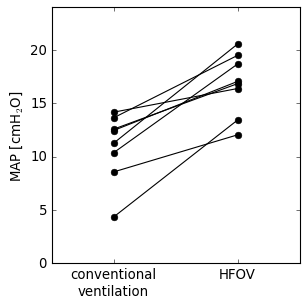

In [27]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot([1, 2], [MAP_conventional_hfov['conventional'], MAP_conventional_hfov['hfov']], color = 'black', marker = 'o')
ax.set_xlim(0.5, 2.5)
ax.set_ylim(0, 24)
ax.set_xticks([1,2])
ax.set_xticklabels(['conventional\nventilation', 'HFOV'], size = 12)
ax.set_ylabel('MAP [cmH$_2$O]', size = 12)
ax.set_title('', size = 12)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'MAP_conventional_hfov.{filetype}'), dpi = dpi,format = filetype, bbox_inches= 'tight')

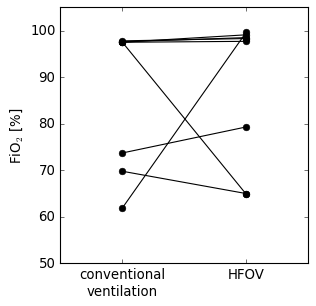

In [28]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot([1, 2], [FiO2_conventional_hfov['conventional'], FiO2_conventional_hfov['hfov']], color = 'black', marker = 'o')
ax.set_xlim(0.5, 2.5)
ax.set_ylim(50, 105)
ax.set_xticks([1,2])
ax.set_xticklabels(['conventional\nventilation', 'HFOV'], size = 12)
ax.set_ylabel('FiO$_2$ [%]', size = 12)
ax.set_title('', size = 12)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'FiO2_conventional_hfov.{filetype}'), dpi = dpi,format = filetype, bbox_inches= 'tight')

### 5. Analyse parameters in all HFOV recordings (limiting only to HFOV parts)

#### A. In all recordings together

The problem with this that the various recording are of different length and therefore it is a skewed dataset

In [29]:
# Only consider parameters which are relevant and interpretable for both HFOV-VG and HFOV without VG
pars_for_stats = ['FiO2', 'MAP', 'Leak', 'Flow_insp_set', 'HFOV_freq',
                  'deltaP', 'VThf_emand_kg', 'DCO2_kg2',
                  'FiO2_diff', 'abs_FiO2_diff', 'MAP_diff', 'abs_MAP_diff', 'HFOV_freq_diff', 'abs_HFOV_freq_diff',]

In [30]:
stats_hfov_only_combined = round(data_pars_hfov_only_combined[pars_for_stats].describe(percentiles=percentiles), 2)
stats_hfov_only_combined

,FiO2,MAP,Leak,Flow_insp_set,HFOV_freq,deltaP,VThf_emand_kg,DCO2_kg2,FiO2_diff,abs_FiO2_diff,MAP_diff,abs_MAP_diff,HFOV_freq_diff,abs_HFOV_freq_diff
count,80961.00,80961.00,80961.00,80961.00,80951.00,80951.00,80951.00,80951.00,80961.00,80961.00,80961.00,80961.00,80951.00,80951.00
mean,78.74,14.31,1.91,11.16,8.85,37.23,1.99,40.88,-1.46,1.87,-0.63,0.65,-0.24,0.25
std,24.60,3.53,6.74,2.58,1.51,10.84,0.78,34.00,7.29,7.20,2.20,2.19,1.11,1.11
min,20.00,0.00,0.00,9.00,0.00,0.20,0.00,0.00,-79.50,0.00,-25.00,0.00,-12.00,0.00
1%,20.30,0.00,0.00,9.00,2.00,10.00,0.00,0.00,-24.58,0.00,-16.00,0.00,-7.00,0.00
5%,24.80,9.50,0.00,10.00,7.00,21.20,0.52,1.92,-3.00,0.00,-0.80,0.10,-2.00,0.00
25%,65.20,12.40,0.00,10.00,8.00,28.30,1.61,22.73,-2.00,0.30,-0.50,0.20,0.00,0.00
50%,90.10,13.90,0.00,10.00,9.00,38.40,2.06,35.67,-0.50,0.70,-0.30,0.30,0.00,0.00
75%,97.90,16.60,0.00,11.00,10.00,44.80,2.30,49.07,0.10,2.00,-0.20,0.50,0.00,0.00
95%,99.50,19.80,12.00,20.00,11.00,51.70,3.28,88.19,0.70,3.10,-0.10,0.80,0.00,2.00


#### B. In the individual recordings

##### **MAP**, **DeltaP** and **VThf** are normally distributed, **FiO2**, **Leak**, **frequency**, **DCO2** and **circuit flow** are not

In [31]:
# Parameters showing approximately normal distribution within the individual recordings
pars_for_mean = ['MAP', 'deltaP', 'VThf_emand_kg',]
# Parameters not showing normal distribution within the individual recordings
pars_for_median = ['FiO2', 'Leak', 'Flow_insp_set', 'HFOV_freq', 'DCO2_kg2',
                   'FiO2_diff', 'abs_FiO2_diff', 'MAP_diff', 'abs_MAP_diff', 'HFOV_freq_diff', 'abs_HFOV_freq_diff',]

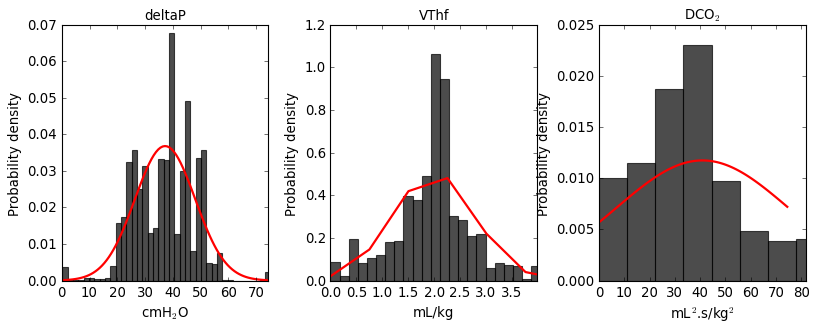

In [32]:
filetype = 'jpg'; dpi = 200

fig, ax = plt.subplots(1,3, figsize = [12, 4])
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.4)
ax = ax.ravel()

data = data_pars_hfov_combined['deltaP']
ax[0].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[0].plot(x, p, linewidth=2, color = 'red')
ax[0].set_xlabel('cmH$_2$O', size = 12)
ax[0].set_ylabel('Probability density', size = 12)
ax[0].set_xlim(0, data.mean()*2)
ax[0].set_title('deltaP', fontsize = 12)

data = data_pars_hfov_combined['VThf_emand_kg']
ax[1].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[1].plot(x, p, linewidth=2, color = 'red')
ax[1].set_xlabel('mL/kg', size = 12)
ax[1].set_ylabel('Probability density', size = 12)
ax[1].set_xlim(0, data.mean()*2)
ax[1].set_title('VThf', fontsize = 12)

data = data_pars_hfov_combined['DCO2_kg2']
ax[2].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[2].plot(x, p, linewidth=2, color = 'red')
ax[2].set_xlabel('mL$^2$.s/kg$^2$', size = 12)
ax[2].set_ylabel('Probability density', size = 12)
ax[2].set_xlim(0, data.mean()*2)
ax[2].set_title('DCO$_2$', fontsize = 12)

fig.savefig(os.path.join(DIR_WRITE, f'hfov_only_deltaP_VThf_DCO2_with_pdf.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight')

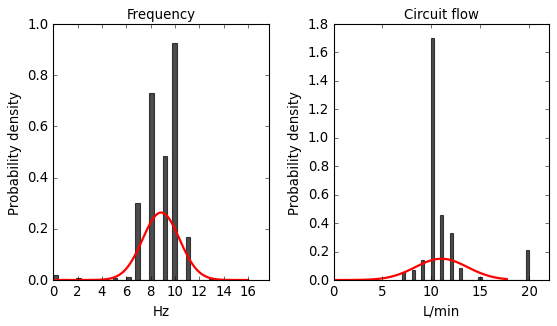

In [33]:
filetype = 'jpg'; dpi = 200

fig, ax = plt.subplots(1,2, figsize = [8, 4])
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.4)
ax = ax.ravel()

data = data_pars_hfov_combined['HFOV_freq']
ax[0].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[0].plot(x, p, linewidth=2, color = 'red')
ax[0].set_xlabel('Hz', size = 12)
ax[0].set_ylabel('Probability density', size = 12)
ax[0].set_xlim(0, data.mean()*2)
ax[0].set_title('Frequency', fontsize = 12)

data = data_pars_hfov_combined['Flow_insp_set']
ax[1].hist(data, histtype = 'bar', bins = 40, density = True, color = 'black', alpha = 0.7, )    
# Plot the PDF.
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp.stats.norm.pdf(x, data.mean(), data.std())
ax[1].plot(x, p, linewidth=2, color = 'red')
ax[1].set_xlabel('L/min', size = 12)
ax[1].set_ylabel('Probability density', size = 12)
ax[1].set_xlim(0, data.mean()*2)
ax[1].set_title('Circuit flow', fontsize = 12)

fig.savefig(os.path.join(DIR_WRITE, f'hfov_only_freq_circuit_flow_with_pdf.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight')


In [34]:
# Stats in the individual recordings
stats_hfov_only = data_pars_hfov_only_combined.groupby(level=0)[pars_for_stats].describe()
stats_hfov_only.head(2)

FiO2                                                        MAP  \
           count       mean       std   min   25%   50%   75%   max   count   
case                                                                          
AT000033  1215.0  96.851440  1.276461  77.3  96.3  96.9  97.8  98.3  1215.0   
AT000034   827.0  97.465659  0.768874  94.4  96.7  97.4  98.2  98.6   827.0   

                                                               Leak            \
               mean       std   min   25%   50%   75%   max   count      mean   
case                                                                            
AT000033  14.675062  0.598140   0.0  14.7  14.7  14.7  16.0  1215.0  0.080658   
AT000034  15.214510  0.475203  14.5  14.7  15.6  15.7  15.7   827.0  0.310762   

                                             Flow_insp_set                   \
               std  min  25%  50%  75%   max         count  mean  std   min   
case                                                                          
AT000033  1.624589  0.0  0.0  0.0  0.0  34.0        1215.0  10.0  0.0  10.0   
AT000034  4.635521  0.0  0.0  0.0  0.0  86.0         827.0  10.0  0.0  10.0   

                                 HFOV_freq                                   \
           25%   50%   75%   max     count       mean       std   min   25%   
case                                                                          
AT000033  10.0  10.0  10.0  10.0    1215.0  10.000000  0.000000  10.0  10.0   
AT000034  10.0  10.0  10.0  10.0     827.0   9.981862  0.173023   7.0  10.0   

                            deltaP                                         \
           50%   75%   max   count       mean       std   min   25%   50%   
case                                                                        
AT000033  10.0  10.0  10.0  1215.0  23.261481  1.130241  21.8  22.7  22.9   
AT000034  10.0  10.0  10.0   827.0  44.782225  0.617706  37.8  44.4  44.7   

                     VThf_emand_kg                                     \
           75%   max         count      mean       std  min       25%   
case                                                                    
AT000033  23.2  33.9        1215.0  2.337668  0.033133  2.2  2.333333   
AT000034  45.2  46.6         827.0  1.567170  0.200215  0.4  1.450000   

                                       DCO2_kg2                             \
               50%       75%       max    count       mean       std   min   
case                                                                         
AT000033  2.333333  2.333333  2.666667   1215.0  54.427801  1.572231  48.0   
AT000034  1.650000  1.700000  1.800000    827.0  24.823156  5.612427   1.5   

                                                     FiO2_diff            \
                25%        50%        75%        max     count      mean   
case                                                                       
AT000033  54.222222  54.222222  54.222222  71.111111    1215.0 -3.148560   
AT000034  21.000000  27.000000  28.750000  32.250000     827.0 -2.534341   

                                             abs_FiO2_diff            \
               std   min  25%  50%  75%  max         count      mean   
case                                                                   
AT000033  1.276461 -22.7 -3.7 -3.1 -2.2 -1.7        1215.0  3.148560   
AT000034  0.768874  -5.6 -3.3 -2.6 -1.8 -1.4         827.0  2.534341   

                                             MAP_diff                      \
               std  min  25%  50%  75%   max    count      mean       std   
case                                                                        
AT000033  1.276461  1.7  2.2  3.1  3.7  22.7   1215.0 -0.324938  0.598140   
AT000034  0.768874  1.4  1.8  2.6  3.3   5.6    827.0 -0.328416  0.062069   

                                   abs_MAP_diff                                \
           min  25%  50%  75%  max        count      mean       st

In [35]:
# Group stats
group_stats_hfov_only_mean = round(stats_hfov_only.swaplevel(axis=1)['mean'][pars_for_mean].describe(percentiles = percentiles), 2)
group_stats_hfov_only_mean.rename(lambda x:f'{x}_mean', axis=1, inplace=True)
group_stats_hfov_only_mean

,MAP_mean,deltaP_mean,VThf_emand_kg_mean
count,51.00,51.00,51.00
mean,14.08,37.13,2.00
std,2.66,10.21,0.63
min,9.43,19.02,0.47
1%,9.52,19.87,0.61
5%,10.56,21.29,1.04
25%,12.31,28.77,1.70
50%,13.70,38.96,2.02
75%,15.59,43.87,2.27
95%,19.09,51.17,2.96


In [36]:
# Group stats
group_stats_hfov_only_median = round(stats_hfov_only.swaplevel(axis=1)['50%'][pars_for_median].describe(percentiles = percentiles), 2)
group_stats_hfov_only_median.rename(lambda x:f'{x}_median', axis=1, inplace=True)
group_stats_hfov_only_median

,FiO2_median,Leak_median,Flow_insp_set_median,HFOV_freq_median,DCO2_kg2_median,FiO2_diff_median,abs_FiO2_diff_median,MAP_diff_median,abs_MAP_diff_median,HFOV_freq_diff_median,abs_HFOV_freq_diff_median
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,79.80,1.49,11.02,9.02,40.52,-0.85,1.10,-0.33,0.33,-0.06,0.06
std,23.13,4.61,2.44,1.17,27.26,1.08,0.86,0.16,0.16,0.42,0.42
min,20.50,0.00,9.00,7.00,1.65,-3.10,0.10,-0.70,0.10,-3.00,0.00
1%,22.75,0.00,9.00,7.00,3.82,-3.05,0.15,-0.70,0.10,-1.50,0.00
5%,27.60,0.00,10.00,7.00,10.26,-2.70,0.25,-0.50,0.10,0.00,0.00
25%,69.65,0.00,10.00,8.00,24.46,-1.70,0.40,-0.43,0.20,0.00,0.00
50%,89.60,0.00,10.00,9.00,35.65,-0.50,0.70,-0.30,0.30,0.00,0.00
75%,97.90,0.00,11.00,10.00,49.02,0.00,1.70,-0.20,0.45,0.00,0.00
95%,99.00,11.00,16.50,10.00,85.85,0.45,2.70,-0.10,0.50,0.00,0.00


In [37]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_hfov_only.xlsx'))
stats_hfov_only_combined.to_excel(writer, 'stats_combined')
stats_hfov_only.to_excel(writer, 'stats_recordings')
group_stats_hfov_only_mean.to_excel(writer, 'group_stats_mean')
group_stats_hfov_only_median.to_excel(writer, 'group_stats_median')
writer.close()

##### FiO2

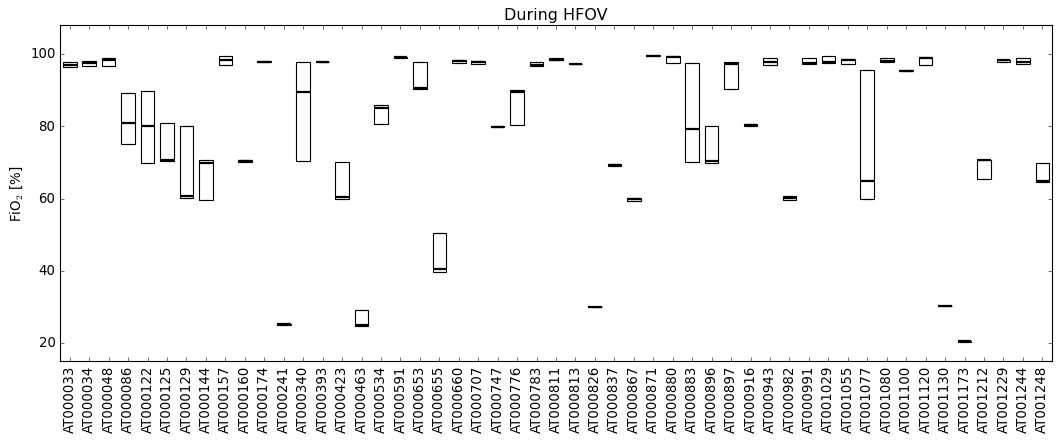

In [38]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (16, 6))
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=None, hspace=None)

data = data_pars_hfov_only_combined['FiO2'].groupby(level=0)
data_for_graph = [item[1].dropna() for item in data]
xticklabels = [item[0] for item in data]

# Shows median and interquartile range
ax.boxplot(data_for_graph, widths=0.7, whis = 0, patch_artist = True, showfliers = False,
    showmeans = False, medianprops=medianprops, meanprops = meanprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, )

ax.set_ylim(15, 108)
ax.set_xticklabels(xticklabels, rotation='vertical')
ax.set_ylabel('FiO$_2$ [%]')
ax.set_title('During HFOV')
    
fig.savefig(os.path.join(DIR_WRITE, f'hfov_only_FiO2_boxplot.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight')

### 6. Analyse parameters in HFOV-VG recordings

#### A. In all recordings together

The problem with this that the various recording are of different length and therefore it is a skewed dataset

In [39]:
# Only consider parameters which are relevant and interpretable for HFOV-VG
# DeltaP_diff here means the difference between deltaP and amplmax(it should be a negative number, as amplmax should be larger than 
# the actual deltaP

pars_for_stats = ['FiO2', 'MAP', 'Leak',  'Flow_insp_set', 
                  'HFOV_freq', 'deltaP', 'VThf_emand_kg', 'VG_set_kg', 'DCO2_kg2',
                  'FiO2_diff', 'abs_FiO2_diff', 'MAP_diff', 'abs_MAP_diff', 'HFOV_freq_diff', 'abs_HFOV_freq_diff',
                  'VThf_diff_kg', 'abs_VThf_diff_kg', 'deltaP_diff', 'abs_deltaP_diff',]

In [40]:
# All recordings together
stats_hfov_vg_only_combined = round(data_pars_hfov_vg_only_combined[pars_for_stats].describe(percentiles=percentiles), 2)
stats_hfov_vg_only_combined

,FiO2,MAP,Leak,Flow_insp_set,HFOV_freq,deltaP,VThf_emand_kg,VG_set_kg,DCO2_kg2,FiO2_diff,abs_FiO2_diff,MAP_diff,abs_MAP_diff,HFOV_freq_diff,abs_HFOV_freq_diff,VThf_diff_kg,abs_VThf_diff_kg,deltaP_diff,abs_deltaP_diff
count,42108.00,42108.00,42108.00,42108.00,42107.00,42107.00,42107.00,42108.00,42107.00,42108.00,42108.00,42108.00,42108.00,42107.00,42107.00,42107.00,42107.00,42107.00,42107.00
mean,72.61,13.80,1.06,11.12,8.75,38.76,1.99,2.28,38.93,-1.68,2.07,-0.73,0.75,-0.29,0.29,-0.29,0.32,-9.15,9.62
std,27.63,3.71,5.04,2.63,1.55,10.94,0.62,0.37,22.52,8.60,8.52,2.69,2.68,1.16,1.16,0.51,0.49,10.76,10.35
min,20.10,0.00,0.00,9.00,0.00,0.20,0.00,1.37,0.00,-79.50,0.00,-21.50,0.00,-10.00,0.00,-2.61,0.00,-64.50,0.00
1%,20.20,0.00,0.00,9.00,0.00,0.20,0.00,1.37,0.00,-75.80,0.00,-20.70,0.00,-9.00,0.00,-2.07,0.00,-52.80,0.00
5%,20.60,9.20,0.00,9.00,7.00,21.20,0.49,1.97,1.73,-3.20,0.00,-0.80,0.10,-3.00,0.00,-1.59,0.00,-26.80,0.10
25%,59.50,11.60,0.00,10.00,8.00,31.30,1.85,2.10,28.23,-1.80,0.30,-0.40,0.20,0.00,0.00,-0.33,0.03,-15.80,0.80
50%,80.00,13.80,0.00,10.00,8.00,39.40,2.11,2.24,36.73,-0.50,0.60,-0.30,0.30,0.00,0.00,-0.09,0.10,-6.30,6.60
75%,97.70,15.70,0.00,12.00,10.00,48.90,2.27,2.29,49.07,0.10,1.90,-0.20,0.40,0.00,0.00,-0.03,0.34,-0.30,16.00
95%,99.10,19.70,10.00,20.00,11.00,51.70,2.86,2.86,79.15,0.60,3.20,0.00,0.90,0.00,3.00,0.07,1.59,1.20,26.90


#### B. In the individual recordings

In [41]:
# Parameters showing approximately normal distribution within the individual recordings
pars_for_mean = ['MAP', 'deltaP', 'VThf_emand_kg', 'VG_set_kg', ]
# Parameters not showing normal distribution within the individual recordings
pars_for_median = ['FiO2', 'DCO2_kg2', 'Leak', 'HFOV_freq', 'Flow_insp_set',
                  'FiO2_diff', 'abs_FiO2_diff', 'MAP_diff', 'abs_MAP_diff', 'HFOV_freq_diff', 'abs_HFOV_freq_diff',
                  'VThf_diff_kg', 'abs_VThf_diff_kg', 'deltaP_diff', 'abs_deltaP_diff',]

In [42]:
# Stats in the individual recordings
stats_hfov_vg_only = data_pars_hfov_vg_only_combined.groupby(level=0)[pars_for_stats].describe()
stats_hfov_vg_only.head()

FiO2                                                        MAP  \
           count       mean       std   min   25%   50%   75%   max   count   
AT000033  1212.0  96.848845  1.276973  77.3  96.3  96.9  97.8  98.3  1212.0   
AT000034   827.0  97.465659  0.768874  94.4  96.7  97.4  98.2  98.6   827.0   
AT000144  1171.0  67.644492  9.044021  46.5  59.5  69.9  70.7  92.7  1171.0   
AT000160  1527.0  70.395481  0.512107  69.0  70.0  70.4  70.7  71.5  1527.0   
AT000241  3286.0  25.523889  3.839192  23.5  25.0  25.2  25.4  66.2  3286.0   

                                                               Leak            \
               mean       std   min   25%   50%   75%   max   count      mean   
AT000033  14.687211  0.425053   0.0  14.7  14.7  14.7  16.0  1212.0  0.080858   
AT000034  15.214510  0.475203  14.5  14.7  15.6  15.7  15.7   827.0  0.310762   
AT000144  12.279078  1.950914   0.0  11.6  11.7  13.7  15.6  1171.0  0.036721   
AT000160  11.501113  0.423141   0.0  11.5  11.5  11.6  11.9  1527.0  0.000000   
AT000241   9.432380  0.300013   6.6   9.2   9.5   9.7  11.5  3286.0  1.053256   

                                             Flow_insp_set             \
               std  min  25%  50%  75%   max         count       mean   
AT000033  1.626595  0.0  0.0  0.0  0.0  34.0        1212.0  10.000000   
AT000034  4.635521  0.0  0.0  0.0  0.0  86.0         827.0  10.000000   
AT000144  0.514259  0.0  0.0  0.0  0.0   8.0        1171.0  10.257899   
AT000160  0.000000  0.0  0.0  0.0  0.0   0.0        1527.0  10.000000   
AT000241  4.758960  0.0  0.0  0.0  0.0  70.0        3286.0  10.000000   

                                                 HFOV_freq             \
               std   min   25%   50%   75%   max     count       mean   
AT000033  0.000000  10.0  10.0  10.0  10.0  10.0    1212.0  10.000000   
AT000034  0.000000  10.0  10.0  10.0  10.0  10.0     827.0   9.981862   
AT000144  0.441554  10.0  10.0  10.0  11.0  12.0    1171.0   9.692570   
AT000160  0.000000  10.0  10.0  10.0  10.0  10.0    1527.0  11.000000   
AT000241  0.000000  10.0  10.0  10.0  10.0  10.0    3286.0   9.963177   

                                                  deltaP                       \
               std   min   25%   50%   75%   max   count       mean       std   
AT000033  0.000000  10.0  10.0  10.0  10.0  10.0  1212.0  23.259653  1.129587   
AT000034  0.173023   7.0  10.0  10.0  10.0  10.0   827.0  44.782225  0.617706   
AT000144  0.512515   6.0   9.0  10.0  10.0  10.0  1171.0  52.786849  2.687606   
AT000160  0.000000  11.0  11.0  11.0  11.0  11.0  1527.0  45.430517  0.523922   
AT000241  0.197815   8.0  10.0  10.0  10.0  10.0  3286.0  38.964942  1.684549   

                                       VThf_emand_kg                      \
           min   25%   50%   75%   max         count      mean       std   
AT000033  21.8  22.7  22.9  23.2  33.9        1212.0  2.337404  0.032255   
AT000034  37.8  44.4  44.7  45.2  46.6         827.0  1.567170  0.200215   
AT000144  25.3  51.6  52.0  55.3  57.0        1171.0  1.411120  0.180381   
AT000160  44.3  45.0  45.4  45.8  47.7        1527.0  1.368663  0.182690   
AT000241  23.6  38.4  39.3  39.8  45.9        3286.0  2.192800  0.092615   

                                                           VG_set_kg  \
               min       25%       50%       75%       max     count   
AT000033  2.200000  2.333333  2.333333  2.333333  2.666667    1212.0   
AT000034  0.400000  1.450000  1.650000  1.700000  1.800000     827.0   
AT000144  0.578947  1.368421  1.447368  1.526316  1.657895    1171.0   
AT000160  0.796915  1.285347  1.388175  1.439589  1.773779    1527.0   
AT000241  1.193182  2.159091  2.215909  2.244318  2.613636    3286.0   

                                                                          \
              mean           std       min       25%       50%       75%   
AT000033  2.400000  5.331270e-14  2.400000  2.400000  2.400000  2.400000   
AT000034  2.300000  3.066070e-14

In [43]:
# Group stats
group_stats_hfov_vg_only_mean = round(stats_hfov_vg_only.swaplevel(axis=1)['mean'][pars_for_mean].describe(percentiles = percentiles), 2)
group_stats_hfov_vg_only_mean.rename(lambda x:f'{x}_mean', axis=1, inplace=True)
group_stats_hfov_vg_only_mean

,MAP_mean,deltaP_mean,VThf_emand_kg_mean,VG_set_kg_mean
count,26.00,26.00,26.00,26.00
mean,13.93,39.19,2.00,2.30
std,2.65,9.75,0.53,0.47
min,9.43,19.02,0.47,1.50
1%,9.48,20.08,0.62,1.62
5%,9.89,23.26,1.14,1.99
25%,12.15,32.50,1.82,2.08
50%,14.26,41.15,2.04,2.19
75%,15.50,48.22,2.30,2.37
95%,18.07,50.87,2.68,2.73


In [44]:
# Group stats
group_stats_hfov_vg_only_median = round(stats_hfov_vg_only.swaplevel(axis=1)['50%'][pars_for_median].describe(percentiles = percentiles), 2)
group_stats_hfov_vg_only_median.rename(lambda x:f'{x}_median', axis=1, inplace=True)
group_stats_hfov_vg_only_median

,FiO2_median,DCO2_kg2_median,Leak_median,HFOV_freq_median,Flow_insp_set_median,FiO2_diff_median,abs_FiO2_diff_median,MAP_diff_median,abs_MAP_diff_median,HFOV_freq_diff_median,abs_HFOV_freq_diff_median,VThf_diff_kg_median,abs_VThf_diff_kg_median,deltaP_diff_median,abs_deltaP_diff_median
count,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00,26.00
mean,75.58,38.61,1.00,8.81,11.12,-0.98,1.15,-0.31,0.31,-0.12,0.12,-0.27,0.28,-7.98,8.27
std,26.97,18.11,3.63,1.17,2.78,1.09,0.94,0.15,0.15,0.59,0.59,0.40,0.40,9.27,9.05
min,20.50,1.65,0.00,7.00,9.00,-3.10,0.20,-0.70,0.10,-3.00,0.00,-1.59,0.00,-29.20,0.20
1%,21.62,3.94,0.00,7.00,9.00,-3.07,0.20,-0.65,0.10,-2.25,0.00,-1.52,0.00,-28.40,0.23
5%,25.05,13.34,0.00,7.25,9.25,-2.90,0.23,-0.50,0.10,0.00,0.00,-1.14,0.01,-24.90,0.32
25%,64.90,29.43,0.00,8.00,10.00,-1.88,0.40,-0.40,0.20,0.00,0.00,-0.38,0.07,-14.55,0.68
50%,84.70,34.15,0.00,8.00,10.00,-0.60,0.65,-0.30,0.30,0.00,0.00,-0.07,0.09,-4.00,4.67
75%,97.78,51.78,0.00,10.00,11.00,-0.10,1.88,-0.20,0.40,0.00,0.00,-0.06,0.38,-0.35,14.55
95%,98.80,68.50,7.50,10.75,18.25,0.20,2.90,-0.10,0.50,0.00,0.00,0.00,1.14,0.40,24.90


In [45]:
# For VThf and deltaP, also calculate group statistics on variability (use sd as these show parametric distribution)
group_stats_hfov_vg_only_sd = round(stats_hfov_vg_only.swaplevel(axis=1)['std'][['VThf_emand_kg', 'deltaP']].describe(percentiles 
                                                                                                                      = percentiles), 2)
group_stats_hfov_vg_only_sd.rename(lambda x:f'{x}_sd', axis=1, inplace=True)
group_stats_hfov_vg_only_sd

,VThf_emand_kg_sd,deltaP_sd
count,26.00,26.00
mean,0.21,4.14
std,0.17,3.92
min,0.03,0.32
1%,0.04,0.34
5%,0.06,0.42
25%,0.13,1.14
50%,0.18,2.74
75%,0.26,7.25
95%,0.35,10.53


In [46]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_hfov_vg_only.xlsx'))
stats_hfov_vg_only_combined.to_excel(writer, 'stats_combined')
stats_hfov_vg_only.to_excel(writer, 'stats_recordings')
group_stats_hfov_vg_only_mean.to_excel(writer, 'group_stats_mean')
group_stats_hfov_vg_only_median.to_excel(writer, 'group_stats_median')
group_stats_hfov_vg_only_sd.to_excel(writer, 'group_stats_sd')
writer.close()

##### Amplitude - Amplitude set

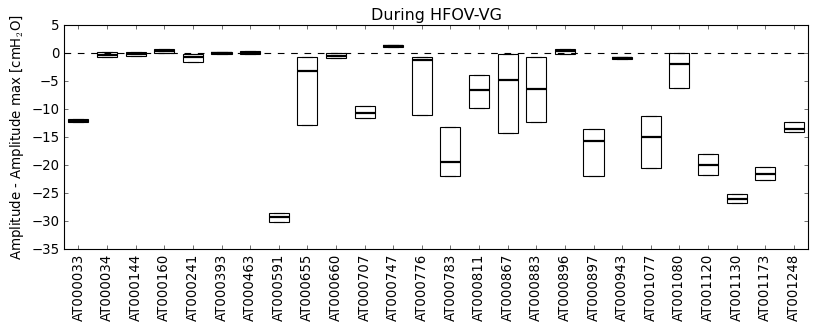

In [47]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (12, 4))
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=None, hspace=None)

data = data_pars_hfov_vg_only_combined['deltaP_diff'].groupby(level=0)
data_for_graph = [item[1].dropna() for item in data]
xticklabels = [item[0] for item in data]

ax.boxplot(data_for_graph, widths=0.7, whis = 0, patch_artist = True, showfliers = False, showmeans = False, medianprops=medianprops, 
    meanprops = meanprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, )
ax.hlines(0, *ax.get_xlim(), color='black', linestyle='--')

ax.set_xticklabels(xticklabels, rotation='vertical')
ax.set_ylabel('Amplitude - Amplitude max [cmH$_2$O]')
ax.set_title('During HFOV-VG')
    
fig.savefig(os.path.join(DIR_WRITE, f'hfov_vg_only_deltaP_diff_boxplot.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight')

##### VThf - VThf set

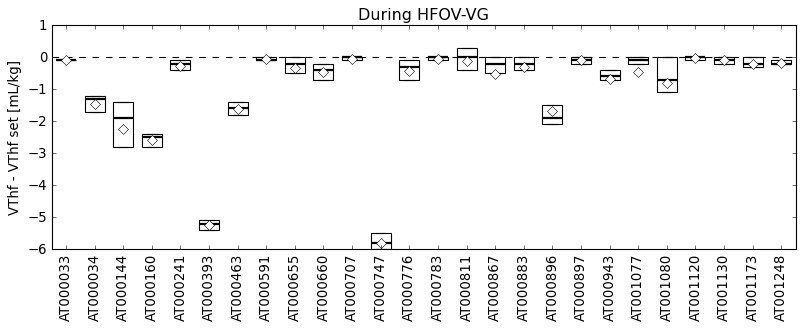

In [48]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (12, 4))
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=None, hspace=None)

data = data_pars_hfov_vg_only_combined['VThf_diff'].groupby(level=0)
data_for_graph = [item[1].dropna() for item in data]
xticklabels = [item[0] for item in data]

ax.boxplot(data_for_graph, widths=0.7, whis = 0, patch_artist = True, showfliers = False, showmeans = True, medianprops=medianprops, 
    meanprops = meanprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, )
ax.hlines(0, *ax.get_xlim(), color='black', linestyle='--')

ax.set_xticklabels(xticklabels, rotation='vertical')
ax.set_ylabel('VThf - VThf set [mL/kg]')
ax.set_title('During HFOV-VG')
    
fig.savefig(os.path.join(DIR_WRITE, f'hfov_vg_only_VThf_diff_boxplot.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight')

#### C. Consider only periods when amplitude (deltaP) did not reach the set amplitude_max (deltaP_max)

##### How frequently did amplitude reach the maximum allowed amplitude ?

In [49]:
VG_not_limited_by_amplmax = data_pars_hfov_vg_only_combined[data_pars_hfov_vg_only_combined['deltaP_diff'] < 0]
VG_limited_by_amplmax = data_pars_hfov_vg_only_combined[data_pars_hfov_vg_only_combined['deltaP_diff'] >= 0]

In [50]:
len(VG_limited_by_amplmax) / len(data_pars_hfov_vg_only_combined)

0.21069630474019188

In [51]:
proportion_limited_by_Amplmax = DataFrame(VG_limited_by_amplmax.groupby(level=0).size() / 
    data_pars_hfov_vg_only_combined.groupby(level=0).size() * 100, columns=['limited by Amplmax [%]'])
# NAs refer to recordings where Amp never reached Ampl_max, replace them with zero
proportion_limited_by_Amplmax.replace(np.nan, 0, inplace=True)
proportion_limited_by_Amplmax

,limited by Amplmax [%]
AT000033,0.000000
AT000034,34.582830
AT000144,36.208369
AT000160,78.258022
AT000241,20.663421
AT000393,63.777490
AT000463,63.111111
AT000591,0.000000
AT000655,12.639594
AT000660,26.984127


In [52]:
# Stats to analyse
pars_for_stats = ['VThf_diff_kg', 'abs_VThf_diff_kg',]

stats_VG_not_limited_by_amplmax = VG_not_limited_by_amplmax.groupby(level=0)[pars_for_stats].describe()
stats_VG_limited_by_amplmax = VG_limited_by_amplmax.groupby(level=0)[pars_for_stats].describe()

# DataFrame containing only median VThf_diffs
median_VThf_diff_by_Amplmax = pd.concat([stats_VG_limited_by_amplmax['VThf_diff_kg']['50%'],
    stats_VG_not_limited_by_amplmax['VThf_diff_kg']['50%'], stats_hfov_vg_only['VThf_diff_kg']['50%']],
        axis=1)
median_VThf_diff_by_Amplmax.columns = ['VThf_diff_kg_limited', 'VThf_diff_kg_not_limited', 'VThf_diff_kg_all']
# NAs refer to recordings where Amp never reached Ampl_max, replace them with zero
median_VThf_diff_by_Amplmax.sort_index(key=np.vectorize(lambda x: int(x[-4:])), inplace=True)
median_VThf_diff_by_Amplmax.head()

,VThf_diff_kg_limited,VThf_diff_kg_not_limited,VThf_diff_kg_all
AT000033,NaN,-0.066667,-0.066667
AT000034,-0.850000,-0.600000,-0.650000
AT000144,-0.657895,-0.447368,-0.500000
AT000160,-0.668380,-0.591260,-0.642674
AT000241,-0.085227,-0.056818,-0.056818


In [53]:
median_VThf_diff_by_Amplmax['VThf_diff_kg_limited'].describe()

count    18.000000
mean     -0.581584
std       0.469122
min      -1.589041
25%      -0.709858
50%      -0.430904
75%      -0.263034
max      -0.085227
Name: VThf_diff_kg_limited, dtype: float64

In [54]:
median_VThf_diff_by_Amplmax['VThf_diff_kg_not_limited'].describe()

count    26.000000
mean     -0.244116
std       0.404290
min      -1.643836
25%      -0.183741
50%      -0.067816
75%      -0.041577
max       0.000000
Name: VThf_diff_kg_not_limited, dtype: float64

In [55]:
median_VThf_diff_by_Amplmax['VThf_diff_kg_all'].describe()

count    26.000000
mean     -0.266919
std       0.403971
min      -1.589041
25%      -0.378767
50%      -0.070979
75%      -0.057765
max       0.000000
Name: VThf_diff_kg_all, dtype: float64

In [56]:
stats_by_Amplmax = round(median_VThf_diff_by_Amplmax.describe(), 2)
stats_by_Amplmax

,VThf_diff_kg_limited,VThf_diff_kg_not_limited,VThf_diff_kg_all
count,18.00,26.00,26.00
mean,-0.58,-0.24,-0.27
std,0.47,0.40,0.40
min,-1.59,-1.64,-1.59
25%,-0.71,-0.18,-0.38
50%,-0.43,-0.07,-0.07
75%,-0.26,-0.04,-0.06
max,-0.09,0.00,0.00


In [57]:
sp.stats.mannwhitneyu(median_VThf_diff_by_Amplmax[('VThf_diff_kg_limited')].dropna(), 
                      median_VThf_diff_by_Amplmax[('VThf_diff_kg_not_limited')])

MannwhitneyuResult(statistic=88.5, pvalue=0.0005348114510115779)

In [58]:
sp.stats.mannwhitneyu(median_VThf_diff_by_Amplmax[('VThf_diff_kg_limited')].dropna(), 
                      median_VThf_diff_by_Amplmax[('VThf_diff_kg_all')])

MannwhitneyuResult(statistic=98.0, pvalue=0.0012129355516484626)

In [59]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'limited_by_amplmax.xlsx'))
proportion_limited_by_Amplmax.to_excel(writer, 'proportion_limited_by_Amplmax')
median_VThf_diff_by_Amplmax.to_excel(writer, 'median_VThf_diff_by_Amplmax')
stats_by_Amplmax.to_excel(writer, 'group_stats')
writer.close()

#### D. Consider separately the recordings before and after the quality control and case review meeting in December 2021

On this meeting the explicit recommendation was made to keep Amplmax 10 cmH2O above the usual "working" amplitude

In [60]:
hfov_vg_before_meeting = [recording for recording in data_pars_hfov_vg_only.keys() if int(recording[2:].lstrip('0')) <= 533]
hfov_vg_after_meeting = [recording for recording in data_pars_hfov_vg_only.keys() if int(recording[2:].lstrip('0')) > 533]
len(hfov_vg_before_meeting), len(hfov_vg_after_meeting)

(7, 19)

In [61]:
data_pars_hfov_vg_before_meeting_only_combined = data_pars_hfov_vg_only_combined.loc[hfov_vg_before_meeting]
data_pars_hfov_vg_after_meeting_only_combined = data_pars_hfov_vg_only_combined.loc[hfov_vg_after_meeting]

In [62]:
# Stats to analyse
pars_for_stats = ['VThf_diff_kg', 'abs_VThf_diff_kg', 'deltaP_diff', 'abs_deltaP_diff']

# Stats in the individual recordings
stats_hfov_vg_only_before_meeting = data_pars_hfov_vg_before_meeting_only_combined.groupby(level=0)[pars_for_stats].describe()
stats_hfov_vg_only_after_meeting = data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)[pars_for_stats].describe()

In [63]:
stats_hfov_vg_only_before_meeting

VThf_diff_kg                                                    \
                count      mean       std       min       25%       50%   
AT000033       1212.0 -0.062596  0.032255 -0.200000 -0.066667 -0.066667   
AT000034        827.0 -0.732830  0.200215 -1.900000 -0.850000 -0.650000   
AT000144       1171.0 -0.588791  0.260306 -1.526316 -0.736842 -0.500000   
AT000160       1527.0 -0.666444  0.188751 -1.259640 -0.719794 -0.642674   
AT000241       3286.0 -0.079928  0.092615 -1.079545 -0.113636 -0.056818   
AT000393        773.0 -1.314360  0.082519 -1.850000 -1.350000 -1.300000   
AT000463        900.0 -0.439635  0.079554 -0.712329 -0.493151 -0.438356   

                             abs_VThf_diff_kg                                \
               75%       max            count      mean       std       min   
AT000033 -0.066667  0.266667           1212.0  0.064356  0.028579  0.000000   
AT000034 -0.600000 -0.500000            827.0  0.732830  0.200215  0.500000   
AT000144 -0.368421 -0.236842           1171.0  0.588791  0.260306  0.236842   
AT000160 -0.616967 -0.231362           1527.0  0.666444  0.188751  0.231362   
AT000241 -0.028409  0.340909           3286.0  0.088487  0.084473  0.000000   
AT000393 -1.275000 -0.325000            773.0  1.314360  0.082519  0.325000   
AT000463 -0.383562 -0.301370            900.0  0.439635  0.079554  0.301370   

                                                 deltaP_diff             \
               25%       50%       75%       max       count       mean   
AT000033  0.066667  0.066667  0.066667  0.266667      1212.0 -11.740347   
AT000034  0.600000  0.650000  0.850000  1.900000       827.0  -0.217775   
AT000144  0.368421  0.500000  0.736842  1.526316      1171.0  -0.330145   
AT000160  0.616967  0.642674  0.719794  1.259640      1527.0   0.430517   
AT000241  0.028409  0.056818  0.113636  1.079545      3286.0  -1.035058   
AT000393  1.275000  1.300000  1.350000  1.850000       773.0   0.048124   
AT000463  0.383562  0.438356  0.493151  0.712329       900.0   0.127000   

                                                abs_deltaP_diff             \
               std   min   25%   50%   75%  max           count       mean   
AT000033  1.129587 -13.2 -12.3 -12.1 -11.8 -1.1          1212.0  11.740347   
AT000034  0.617706  -7.2  -0.6  -0.3   0.2  1.6           827.0   0.510883   
AT000144  1.911849 -26.7  -0.5  -0.2   0.2  1.7          1171.0   0.630743   
AT000160  0.523922  -0.7   0.0   0.4   0.8  2.7          1527.0   0.538834   
AT000241  1.684549 -16.4  -1.6  -0.7  -0.2  5.9          3286.0   1.333901   
AT000393  0.324536  -0.8  -0.2   0.0   0.3  1.2           773.0   0.255886   
AT000463  0.537963  -2.1  -0.2   0.1   0.4  7.0           900.0   0.379222   

                                                 
               std  min   25%   50%   75%   max  
AT000033  1.129587  1.1  11.8  12.1  12.3  13.2  
AT000034  0.409544  0.0   0.2   0.5   0.7   7.2  
AT000144  1.834688  0.0   0.2   0.4   0.6  26.7  
AT000160  0.411616  0.0   0.2   0.4   0.8   2.7  
AT000241  1.459295  0.0   0.5   0.9   1.6  16.4  
AT000393  0.205134  0.0   0.1   0.2   0.4   1.2  
AT000463  0.401972  0.0   0.2   0.3   0.5   7.0

In [64]:
stats_hfov_vg_only_after_meeting

VThf_diff_kg                                                    \
                count      mean       std       min       25%       50%   
AT000591        660.0 -0.022239  0.064541 -0.271186 -0.033898 -0.033898   
AT000655       1970.0 -0.105553  0.245165 -2.242424 -0.151515 -0.060606   
AT000660        630.0 -0.133968  0.097222 -0.514286 -0.200000 -0.114286   
AT000707       1415.0 -0.069460  0.124820 -2.571429 -0.142857  0.000000   
AT000747       2497.0 -1.593430  0.125765 -2.136986 -1.643836 -1.589041   
AT000776       2234.0 -0.143790  0.188286 -1.387097 -0.225806 -0.096774   
AT000783        486.0 -0.055091  0.282162 -1.693548 -0.080645  0.000000   
AT000811       1264.0 -0.042064  0.201991 -1.980198 -0.132013  0.000000   
AT000867       1442.0 -0.167558  0.344233 -1.682540 -0.158730 -0.063492   
AT000883       2810.0 -0.114606  0.255714 -2.007299 -0.145985 -0.072993   
AT000896       1335.0 -0.477731  0.235126 -1.400000 -0.600000 -0.542857   
AT000897       1935.0 -0.027268  0.063756 -0.284900 -0.056980 -0.028490   
AT000943       1141.0 -0.220807  0.147913 -1.381579 -0.230263 -0.197368   
AT001077       3198.0 -0.322314  0.888657 -2.137931 -0.137931 -0.068966   
AT001080       1560.0 -0.226996  0.319030 -2.114286 -0.314286 -0.200000   
AT001120       3476.0 -0.047501  0.126398 -1.503759 -0.150376  0.000000   
AT001130        886.0 -0.086957  0.279174 -2.608696 -0.173913 -0.086957   
AT001173       2222.0 -0.067844  0.182201 -1.465798 -0.097720 -0.065147   
AT001248       1250.0 -0.063252  0.138286 -2.129032 -0.064516 -0.064516   

                             abs_VThf_diff_kg                                \
               75%       max            count      mean       std       min   
AT000591  0.000000  0.542373            660.0  0.042681  0.053258  0.000000   
AT000655  0.000000  0.939394           1970.0  0.137671  0.228671  0.000000   
AT000660 -0.057143  0.000000            630.0  0.133968  0.097222  0.000000   
AT000707  0.000000  0.857143           1415.0  0.080767  0.117814  0.000000   
AT000747 -1.506849 -0.301370           2497.0  1.593430  0.125765  0.301370   
AT000776 -0.032258  0.774194           2234.0  0.155659  0.178594  0.000000   
AT000783  0.000000  2.500000            486.0  0.130094  0.256315  0.000000   
AT000811  0.099010  0.363036           1264.0  0.141752  0.149871  0.000000   
AT000867  0.000000  0.698413           1442.0  0.190630  0.332003  0.000000   
AT000883  0.000000  1.313869           2810.0  0.134010  0.246097  0.000000   
AT000896 -0.428571  0.257143           1335.0  0.482825  0.224472  0.000000   
AT000897  0.000000  0.455840           1935.0  0.050767  0.047225  0.000000   
AT000943 -0.131579 -0.098684           1141.0  0.220807  0.147913  0.098684   
AT001077  0.000000  4.827586           3198.0  0.441440  0.835882  0.000000   
AT001080  0.000000  0.885714           1560.0  0.269963  0.283573  0.000000   
AT001120  0.000000  1.654135           3476.0  0.062815  0.119527  0.000000   
AT001130  0.000000  0.608696            886.0  0.137207  0.258189  0.000000   
AT001173  0.000000  0.684039           2222.0  0.098629  0.167541  0.000000   
AT001248 -0.032258  0.096774           1250.0  0.065161  0.137396  0.000000   

                                                 deltaP_diff             \
               25%       50%       75%       max       count       mean   
AT000591  0.000000  0.033898  0.067797  0.542373       660.0 -29.328939   
AT000655  0.030303  0.090909  0.151515  2.242424      1970.0  -7.345127   
AT000660  0.057143  0.114286  0.200000  0.514286       630.0  -0.407460   
AT000707  0.000000  0.000000  0.142857  2.571429      1415.0 -11.375901   
AT000747  1.506849  1.589041  1.643836  2.136986      2497.0   1.143292   
AT000776  0.032258  0.096774  0.258065  1.387097      2234.0  -5.889257   
AT000783  0.000000  0.080645  0.080645  2.500000       486.0 -17.241975   
AT000811  0.033003  0.099010  0.198020  1.980198      1264.0  -6.906408   
AT000867  0.031746  0.0

In [65]:
# Group stats
group_stats_hfov_vg_only_before_meeting_median = \
    round(stats_hfov_vg_only_before_meeting.swaplevel(axis=1)['50%'][pars_for_stats].describe(percentiles = percentiles), 2)
group_stats_hfov_vg_only_before_meeting_median.rename(lambda x:f'{x}_median', axis=1, inplace=True)
group_stats_hfov_vg_only_before_meeting_median

,VThf_diff_kg_median,abs_VThf_diff_kg_median,deltaP_diff_median,abs_deltaP_diff_median
count,7.00,7.00,7.00,7.00
mean,-0.52,0.52,-1.83,2.11
std,0.42,0.42,4.54,4.41
min,-1.30,0.06,-12.10,0.20
1%,-1.26,0.06,-11.42,0.21
5%,-1.10,0.06,-8.68,0.23
25%,-0.65,0.25,-0.50,0.35
50%,-0.50,0.50,-0.20,0.40
75%,-0.25,0.65,0.05,0.70
95%,-0.06,1.10,0.31,8.74


In [66]:
# Group stats
group_stats_hfov_vg_only_after_meeting_median = \
    round(stats_hfov_vg_only_after_meeting.swaplevel(axis=1)['50%'][pars_for_stats].describe(percentiles = percentiles), 2)
group_stats_hfov_vg_only_after_meeting_median.rename(lambda x:f'{x}_median', axis=1, inplace=True)
group_stats_hfov_vg_only_after_meeting_median

,VThf_diff_kg_median,abs_VThf_diff_kg_median,deltaP_diff_median,abs_deltaP_diff_median
count,19.00,19.00,19.00,19.00
mean,-0.17,0.19,-10.25,10.54
std,0.36,0.36,9.62,9.33
min,-1.59,0.00,-29.20,0.60
1%,-1.40,0.00,-28.62,0.60
5%,-0.65,0.00,-26.32,0.60
25%,-0.11,0.06,-17.52,1.70
50%,-0.07,0.09,-6.60,6.70
75%,-0.03,0.11,-1.58,17.52
95%,0.00,0.65,0.49,26.32


In [67]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_before_meeting_only_combined.groupby(level=0)['VThf_diff_kg'].median(),
                      data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)['VThf_diff_kg'].median())

MannwhitneyuResult(statistic=29.0, pvalue=0.03215030665386108)

In [68]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_before_meeting_only_combined.groupby(level=0)['deltaP_diff'].median(),
                      data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)['deltaP_diff'].median())

MannwhitneyuResult(statistic=109.5, pvalue=0.01400123686087268)

In [69]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_before_meeting_only_combined.groupby(level=0)['abs_VThf_diff_kg'].median(),
                      data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)['abs_VThf_diff_kg'].median())

MannwhitneyuResult(statistic=98.0, pvalue=0.07307953158432817)

In [70]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_before_meeting_only_combined.groupby(level=0)['abs_deltaP_diff'].median(),
                      data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)['abs_deltaP_diff'].median())

MannwhitneyuResult(statistic=13.5, pvalue=0.002393878078750709)

In [71]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_hfov_vg_only_before_after_meeting.xlsx'))
stats_hfov_vg_only_after_meeting.to_excel(writer, 'stats_recordings')
group_stats_hfov_vg_only_before_meeting_median.to_excel(writer, 'before_meeting_median')
group_stats_hfov_vg_only_after_meeting_median.to_excel(writer, 'after_meeting_median')
writer.close()

### 7. Analyse parameters in all HFOV recordings without VG

#### A. In all recordings together

The problem with this that the various recording are of different length and therefore it is a skewed dataset

In [72]:
# Only consider parameters which are relevant and interpretable for both HFOV-VG and HFOV without VG
pars_for_stats = ['FiO2', 'MAP', 'Leak', 'Flow_insp_set', 
                  'HFOV_freq', 'deltaP', 'deltaP_set', 'VThf_emand_kg', 'DCO2_kg2', 
                  'FiO2_diff', 'abs_FiO2_diff', 'MAP_diff', 'abs_MAP_diff', 'HFOV_freq_diff', 'abs_HFOV_freq_diff',
                  'deltaP_diff', 'abs_deltaP_diff',]

In [73]:
# All recordings together
stats_hfov_novg_only_combined = round(data_pars_hfov_novg_only_combined[pars_for_stats].describe(percentiles=percentiles), 2)
stats_hfov_novg_only_combined

,FiO2,MAP,Leak,Flow_insp_set,HFOV_freq,deltaP,deltaP_set,VThf_emand_kg,DCO2_kg2,FiO2_diff,abs_FiO2_diff,MAP_diff,abs_MAP_diff,HFOV_freq_diff,abs_HFOV_freq_diff,deltaP_diff,abs_deltaP_diff
count,33157.00,33157.00,33157.00,33157.00,33151.00,33151.00,33157.00,33151.00,33151.00,33157.00,33157.00,33157.00,33157.00,33151.00,33151.00,33151.00,33151.00
mean,87.28,15.19,3.26,10.58,9.01,34.92,34.34,1.99,42.79,-1.40,1.80,-0.52,0.53,-0.22,0.22,0.58,1.51
std,18.18,3.26,8.44,0.77,1.53,9.13,8.53,0.93,37.49,5.87,5.76,1.47,1.46,1.11,1.11,4.00,3.75
min,20.30,0.00,0.00,10.00,0.00,0.20,5.00,0.00,0.00,-79.50,0.00,-25.00,0.00,-12.00,0.00,-54.80,0.00
1%,20.70,10.30,0.00,10.00,2.00,20.20,20.00,0.00,0.00,-4.40,0.00,-5.50,0.00,-7.00,0.00,-4.45,0.00
5%,49.70,11.10,0.00,10.00,7.00,21.00,20.00,0.56,2.23,-2.90,0.10,-0.80,0.10,-1.00,0.00,-0.90,0.10
25%,80.30,12.80,0.00,10.00,9.00,26.70,26.00,1.41,18.51,-2.30,0.40,-0.50,0.20,0.00,0.00,-0.40,0.30
50%,97.30,14.60,0.00,10.00,10.00,36.10,38.00,1.97,36.00,-0.80,0.90,-0.40,0.40,0.00,0.00,0.20,0.60
75%,98.50,17.50,0.00,11.00,10.00,42.10,40.00,2.47,50.70,0.10,2.30,-0.20,0.50,0.00,0.00,0.80,1.00
95%,99.70,19.90,14.00,12.00,10.00,45.90,50.00,3.67,133.28,0.70,2.90,-0.10,0.80,0.00,1.00,6.10,6.40


#### B. In the individual recordings

In [74]:
# Parameters showing approximately normal distribution within the individual recordings
pars_for_mean = ['MAP', 'deltaP', 'VThf_emand_kg',]
# Parameters not showing normal distribution within the individual recordings
pars_for_median = ['FiO2', 'DCO2_kg2', 'Leak', 'HFOV_freq', 'Flow_insp_set',
                  'FiO2_diff', 'abs_FiO2_diff', 'MAP_diff', 'abs_MAP_diff', 'HFOV_freq_diff', 'abs_HFOV_freq_diff',
                  'deltaP_diff', 'abs_deltaP_diff',]

In [75]:
# Stats in the individual recordings
stats_hfov_novg_only = data_pars_hfov_novg_only_combined.groupby(level=0)[pars_for_stats].describe()
stats_hfov_novg_only.head()

FiO2                                                          MAP  \
           count       mean        std   min   25%    50%   75%   max   count   
AT000048  1422.0  97.764276   1.612108  73.6  96.6  98.40  98.8  99.1  1422.0   
AT000086  1021.0  82.780215   8.128964  69.4  75.2  80.80  89.3  97.7  1021.0   
AT000125   796.0  74.826508   5.404853  67.3  70.4  70.70  80.8  90.9   796.0   
AT000129  1270.0  67.914724  10.747281  39.2  60.1  60.70  80.0  80.6  1270.0   
AT000157  1456.0  96.148214  12.693324  20.5  97.1  98.45  99.5  99.8  1456.0   

                                                               Leak  \
               mean       std   min   25%   50%   75%   max   count   
AT000048  15.591280  0.530168   9.2  15.6  15.6  15.7  15.8  1422.0   
AT000086  10.508227  0.318561   4.5  10.5  10.5  10.6  11.3  1021.0   
AT000125  12.555402  0.148310  10.1  12.5  12.6  12.6  13.8   796.0   
AT000129  11.132913  0.171086   7.7  11.1  11.1  11.2  11.9  1270.0   
AT000157  14.412981  0.740300   0.0  14.4  14.6  14.7  16.0  1456.0   

                                                          Flow_insp_set        \
               mean       std  min  25%   50%   75%   max         count  mean   
AT000048   0.492968  5.431386  0.0  0.0   0.0   0.0  65.0        1422.0  10.0   
AT000086  10.233105  5.465087  0.0  8.0  12.0  14.0  21.0        1021.0  10.0   
AT000125   4.785176  4.697954  0.0  0.0   6.0   9.0  13.0         796.0  10.0   
AT000129   0.236220  1.971254  0.0  0.0   0.0   0.0  22.0        1270.0  10.0   
AT000157   2.652473  5.093365  0.0  0.0   0.0   6.0  59.0        1456.0  10.0   

                                            HFOV_freq                       \
          std   min   25%   50%   75%   max     count       mean       std   
AT000048  0.0  10.0  10.0  10.0  10.0  10.0    1422.0  10.000000  0.000000   
AT000086  0.0  10.0  10.0  10.0  10.0  10.0    1021.0   9.964740  0.227369   
AT000125  0.0  10.0  10.0  10.0  10.0  10.0     796.0   9.991206  0.093422   
AT000129  0.0  10.0  10.0  10.0  10.0  10.0    1270.0   9.955118  0.248624   
AT000157  0.0  10.0  10.0  10.0  10.0  10.0    1456.0  10.000000  0.000000   

                                        deltaP                             \
           min   25%   50%   75%   max   count       mean       std   min   
AT000048  10.0  10.0  10.0  10.0  10.0  1422.0  39.649789  0.427350  38.6   
AT000086   8.0  10.0  10.0  10.0  10.0  1021.0  20.714594  0.464581  14.7   
AT000125   9.0  10.0  10.0  10.0  10.0   796.0  40.167211  0.488528  39.2   
AT000129   6.0  10.0  10.0  10.0  10.0  1270.0  24.454567  0.406768  17.5   
AT000157  10.0  10.0  10.0  10.0  10.0  1456.0  30.649176  0.395315  29.2   

                                 deltaP_set                               \
           25%   50%   75%   max      count  mean  std   min   25%   50%   
AT000048  39.3  39.6  39.9  43.1     1422.0  40.0  0.0  40.0  40.0  40.0   
AT000086  20.5  20.7  21.0  22.5     1021.0  20.0  0.0  20.0  20.0  20.0   
AT000125  39.9  40.2  40.4  47.0      796.0  40.0  0.0  40.0  40.0  40.0   
AT000129  24.2  24.4  24.6  25.7     1270.0  25.0  0.0  25.0  25.0  25.0   
AT000157  30.5  30.7  30.9  34.6     1456.0  30.0  0.0  30.0  30.0  30.0   

                     VThf_emand_kg                                          \
           75%   max         count      mean       std       min       25%   
AT000048  40.0  40.0        1422.0  1.628903  0.182257  0.266667  1.566667   
AT000086  20.0  20.0        1021.0  0.755155  0.066995  0.000000  0.732759   
AT000125  40.0  40.0         796.0  1.100829  0.248165  0.831169  0.935065   
AT000129  25.0  25.0        1270.0  3.618999  0.776029  0.000000  3.548387   
AT000157  30.0  30.0        1456.0  2.141600  0.101303  1.784038  2.065728   

                                       DCO2_kg2                         \
               50%       75%       max    count        mean        std   
AT000048  1.666667  1.700000  3.100000   1422.0   26.837553   6

In [76]:
# Group stats
group_stats_hfov_novg_only_mean = round(stats_hfov_novg_only.swaplevel(axis=1)['mean'][pars_for_mean].describe(percentiles = percentiles), 2)
group_stats_hfov_novg_only_mean.rename(lambda x:f'{x}_mean', axis=1, inplace=True)
group_stats_hfov_novg_only_mean

,MAP_mean,deltaP_mean,VThf_emand_kg_mean
count,22.00,22.00,22.00
mean,14.44,33.71,1.99
std,2.84,9.24,0.76
min,10.51,20.71,0.76
1%,10.64,20.78,0.81
5%,11.15,21.05,1.02
25%,12.56,25.25,1.51
50%,13.76,36.56,1.94
75%,15.64,39.78,2.21
95%,20.37,50.42,3.59


In [77]:
# Group stats
group_stats_hfov_novg_only_median = round(stats_hfov_novg_only.swaplevel(axis=1)['50%'][pars_for_median].describe(percentiles = percentiles), 2)
group_stats_hfov_novg_only_median.rename(lambda x:f'{x}_median', axis=1, inplace=True)
group_stats_hfov_novg_only_median

,FiO2_median,DCO2_kg2_median,Leak_median,HFOV_freq_median,Flow_insp_set_median,FiO2_diff_median,abs_FiO2_diff_median,MAP_diff_median,abs_MAP_diff_median,HFOV_freq_diff_median,abs_HFOV_freq_diff_median,deltaP_diff_median,abs_deltaP_diff_median
count,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.0,22.0,22.00,22.00
mean,85.15,43.80,2.27,9.27,10.59,-0.81,1.11,-0.35,0.35,0.0,0.0,0.38,0.75
std,18.24,36.73,5.80,1.20,0.91,1.11,0.81,0.16,0.16,0.0,0.0,1.29,1.13
min,30.00,5.99,0.00,7.00,10.00,-2.80,0.10,-0.70,0.10,0.0,0.0,-0.60,0.30
1%,36.32,6.77,0.00,7.00,10.00,-2.74,0.14,-0.66,0.10,0.0,0.0,-0.58,0.30
5%,60.13,9.80,0.00,7.00,10.00,-2.49,0.30,-0.50,0.10,0.0,0.0,-0.49,0.30
25%,73.12,23.09,0.00,9.00,10.00,-1.68,0.43,-0.49,0.20,0.0,0.0,-0.27,0.30
50%,96.30,37.19,0.00,10.00,10.00,-0.60,0.70,-0.40,0.40,0.0,0.0,0.10,0.45
75%,98.20,48.36,0.00,10.00,11.00,0.08,1.68,-0.20,0.50,0.0,0.0,0.67,0.67
95%,99.07,131.24,11.80,10.00,12.00,0.50,2.49,-0.10,0.50,0.0,0.0,1.27,1.37


In [78]:
# For VThf and deltaP, also calculate group statistics on variability (use sd as these show parametric distribution)
group_stats_hfov_novg_only_sd = round(stats_hfov_novg_only.swaplevel(axis=1)['std'][['VThf_emand_kg', 'deltaP']].describe(percentiles 
                                                                                                                      = percentiles), 2)
group_stats_hfov_novg_only_sd.rename(lambda x:f'{x}_sd', axis=1, inplace=True)
group_stats_hfov_novg_only_sd

,VThf_emand_kg_sd,deltaP_sd
count,22.00,22.00
mean,0.37,2.09
std,0.34,3.51
min,0.05,0.33
1%,0.05,0.34
5%,0.06,0.37
25%,0.14,0.41
50%,0.28,0.59
75%,0.44,1.63
95%,0.87,7.89


In [79]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_hfov_novg_only.xlsx'))
stats_hfov_novg_only_combined.to_excel(writer, 'stats_combined')
stats_hfov_novg_only.to_excel(writer, 'stats_recordings')
group_stats_hfov_novg_only_mean.to_excel(writer, 'group_stats_mean')
group_stats_hfov_novg_only_median.to_excel(writer, 'group_stats_median')
group_stats_hfov_novg_only_sd.to_excel(writer, 'group_stats_sd')
writer.close()

##### Amplitude - Amlitude max

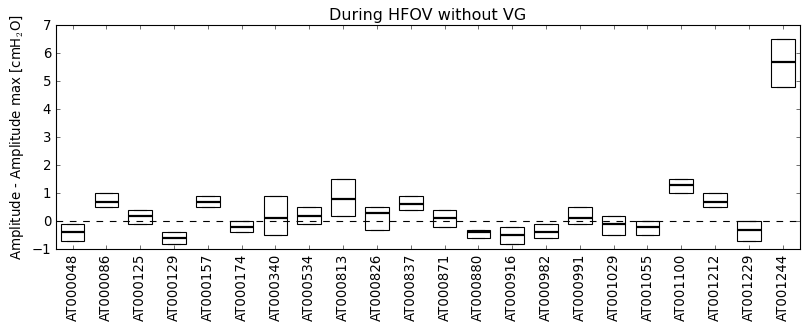

In [80]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (12, 4))
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=None, hspace=None)

data = data_pars_hfov_novg_only_combined['deltaP_diff'].groupby(level=0)
data_for_graph = [item[1].dropna() for item in data]
xticklabels = [item[0] for item in data]

ax.boxplot(data_for_graph, widths=0.7, whis = 0, patch_artist = True, showfliers = False, showmeans = False, medianprops=medianprops, 
    meanprops = meanprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, )
ax.hlines(0, *ax.get_xlim(), color='black', linestyle='--')

ax.set_xticklabels(xticklabels, rotation='vertical')
ax.set_ylabel('Amplitude - Amplitude max [cmH$_2$O]')
ax.set_title('During HFOV without VG')
    
fig.savefig(os.path.join(DIR_WRITE, f'hfov_novg_only_deltaP_diff_boxplot.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight')

### 8. Comparative  analysis of ventilator parameeters between HFOV and HFOV-VG

In [81]:
for par in ['MAP', 'deltaP', 'VThf_emand_kg',]:
    print(par, sp.stats.mannwhitneyu(data_pars_hfov_vg_only_combined.groupby(level=0)[par].mean(),
                                     data_pars_hfov_novg_only_combined.groupby(level=0)[par].mean()))

MAP MannwhitneyuResult(statistic=266.0, pvalue=0.6865902469220198)
deltaP MannwhitneyuResult(statistic=385.0, pvalue=0.041537441562269434)
VThf_emand_kg MannwhitneyuResult(statistic=315.0, pvalue=0.5553842373492123)


In [82]:
for par in ['FiO2', 'DCO2_kg2',]:
    print(par, sp.stats.mannwhitneyu(data_pars_hfov_vg_only_combined.groupby(level=0)[par].median(),
                                     data_pars_hfov_novg_only_combined.groupby(level=0)[par].median()))

FiO2 MannwhitneyuResult(statistic=223.5, pvalue=0.19942407744547197)
DCO2_kg2 MannwhitneyuResult(statistic=303.0, pvalue=0.732793601636438)


#### A. VThf - mean and SD of the recordings

In [83]:
data_pars_hfov_vg_only_combined.groupby(level=0)['VThf_emand_kg'].mean().describe()

count    26.000000
mean      1.996713
std       0.525464
min       0.468485
25%       1.824962
50%       2.041394
75%       2.304878
max       2.935640
Name: VThf_emand_kg, dtype: float64

In [84]:
data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)['VThf_emand_kg'].mean().describe()

count    19.000000
mean      2.054866
std       0.471513
min       0.468485
25%       1.927601
50%       2.045328
75%       2.306210
max       2.709103
Name: VThf_emand_kg, dtype: float64

In [85]:
data_pars_hfov_novg_only_combined.groupby(level=0)['VThf_emand_kg'].mean().describe()

count    22.000000
mean      1.993327
std       0.761273
min       0.755155
25%       1.509517
50%       1.942705
75%       2.209706
max       3.747736
Name: VThf_emand_kg, dtype: float64

In [86]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_only_combined.groupby(level=0)['VThf_emand_kg'].mean(),
                      data_pars_hfov_novg_only_combined.groupby(level=0)['VThf_emand_kg'].mean())

MannwhitneyuResult(statistic=315.0, pvalue=0.5553842373492123)

In [87]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)['VThf_emand_kg'].mean(),
                      data_pars_hfov_novg_only_combined.groupby(level=0)['VThf_emand_kg'].mean())

MannwhitneyuResult(statistic=246.0, pvalue=0.3399476227292103)

In [88]:
data_pars_hfov_vg_only_combined.groupby(level=0)['VThf_emand_kg'].std().describe()

count    26.000000
mean      0.213572
std       0.165642
min       0.032255
25%       0.125024
50%       0.183210
75%       0.262993
max       0.911682
Name: VThf_emand_kg, dtype: float64

In [89]:
data_pars_hfov_vg_after_meeting_only_combined.groupby(level=0)['VThf_emand_kg'].std().describe()

count    19.000000
mean      0.245257
std       0.181294
min       0.049791
25%       0.153283
50%       0.201991
75%       0.276881
max       0.911682
Name: VThf_emand_kg, dtype: float64

In [90]:
data_pars_hfov_novg_only_combined.groupby(level=0)['VThf_emand_kg'].std().describe()

count    22.000000
mean      0.372917
std       0.343940
min       0.049828
25%       0.140978
50%       0.279248
75%       0.437999
max       1.452028
Name: VThf_emand_kg, dtype: float64

In [91]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_only_combined.groupby(level=0)['VThf_emand_kg'].std(),
                      data_pars_hfov_novg_only_combined.groupby(level=0)['VThf_emand_kg'].std())

MannwhitneyuResult(statistic=207.0, pvalue=0.1043134080466564)

#### B. Amplitude

In [92]:
data_pars_hfov_vg_only_combined.groupby(level=0)['deltaP'].mean().describe()

count    26.000000
mean     39.186126
std       9.746121
min      19.017720
25%      32.504466
50%      41.150046
75%      48.224172
max      52.786849
Name: deltaP, dtype: float64

In [93]:
data_pars_hfov_novg_only_combined.groupby(level=0)['deltaP'].mean().describe()

count    22.000000
mean     33.709003
std       9.238217
min      20.714594
25%      25.250057
50%      36.555791
75%      39.776745
max      51.190803
Name: deltaP, dtype: float64

In [94]:
sp.stats.mannwhitneyu(data_pars_hfov_vg_only_combined.groupby(level=0)['deltaP'].mean(),
                      data_pars_hfov_novg_only_combined.groupby(level=0)['deltaP'].mean())

MannwhitneyuResult(statistic=385.0, pvalue=0.041537441562269434)

### 9. Analyse blood gases

#### A. Blood gases at the end of recordings, compare HFOV-VG and noVG

In [95]:
recordings_with_hfov_vg = sorted(data_pars_hfov_vg_only.keys())
recordings_with_hfov_novg = sorted(data_pars_hfov_novg_only.keys())

len(recordings_with_hfov_vg), len(recordings_with_hfov_novg)

(26, 22)

In [96]:
blood_gases_hfov_vg = {recording:data for recording, data in blood_gases_hfov.items() if recording in recordings_with_hfov_vg}
blood_gases_hfov_vg_combined = pd.concat(blood_gases_hfov_vg)
blood_gases_hfov_vg_combined.index.set_names(['recording', 'datetime'], inplace=True)

for column in blood_gases_hfov_vg_combined:
    if column != 'Type':
       blood_gases_hfov_vg_combined[column] = blood_gases_hfov_vg_combined[column].astype('float') 

# If there are multiple blood gases, keep only the last one, that is, at the end of transfer
# There is always a blood gas at the end of transfer
blood_gases_hfov_vg_combined = blood_gases_hfov_vg_combined.reset_index().drop_duplicates(subset=['recording'], keep='last',)
blood_gases_hfov_vg_combined = blood_gases_hfov_vg_combined.set_index('recording')

blood_gases_hfov_vg_combined.head()

,datetime,pH,pCO2,pO2,HCO3,ABE,Saturatio,FiO2,Type
recording,,,,,,,,,
AT000033,2020-11-20 10:12:00,7.370,46.0,52.0,26.6,1.3,85.0,1.00,Capillaris
AT000034,2020-11-20 11:50:00,7.010,94.0,25.0,23.7,-10.3,20.0,1.00,Capillaris
AT000144,2021-02-23 12:01:00,7.170,54.1,47.6,16.9,-8.1,91.6,0.70,Art
AT000160,2021-03-06 13:46:00,7.205,75.3,63.0,23.1,1.8,93.4,0.70,Capillaris
AT000241,2021-05-17 23:07:00,7.011,37.6,35.4,9.4,-21.6,62.4,0.25,Capillaris


In [97]:
blood_gases_hfov_novg = {recording:data for recording, data in blood_gases_hfov.items() if recording in recordings_with_hfov_novg}
blood_gases_hfov_novg_combined = pd.concat(blood_gases_hfov_novg)
blood_gases_hfov_novg_combined.index.set_names(['recording', 'datetime'], inplace=True)

for column in blood_gases_hfov_novg_combined:
    if column != 'Type':
       blood_gases_hfov_novg_combined[column] = blood_gases_hfov_novg_combined[column].astype('float') 

blood_gases_hfov_novg_combined = blood_gases_hfov_novg_combined.reset_index().drop_duplicates(subset=['recording'], keep='last',)
blood_gases_hfov_novg_combined = blood_gases_hfov_novg_combined.set_index('recording')

blood_gases_hfov_novg_combined.head()

,datetime,pH,pCO2,pO2,HCO3,ABE,Saturatio,FiO2,Type
recording,,,,,,,,,
AT000048,2020-12-05 10:03:00,7.070,67.0,57.0,19.4,-10.0,75.0,NaN,NaN
AT000086,2021-01-04 12:00:00,7.170,71.0,52.0,25.9,-2.6,76.0,0.7,Capillaris
AT000125,2021-02-08 15:58:00,7.032,102.0,31.0,17.7,-3.7,57.6,0.8,Capillaris
AT000129,2021-02-11 12:30:00,7.454,38.3,33.4,26.6,3.0,79.8,0.6,Capillaris
AT000157,2021-03-05 10:13:00,7.259,58.9,50.4,21.8,-0.8,88.1,1.0,Capillaris


In [98]:
blood_gases_hfov_vg_combined.describe()

,datetime,pH,pCO2,pO2,HCO3,ABE,Saturatio,FiO2
count,26,25.000000,24.000000,24.000000,23.000000,23.000000,23.000000,23.000000
mean,2022-06-05 19:01:04.615384320,7.227560,57.116667,47.745833,21.095652,-4.065217,80.926087,0.800870
min,2020-11-20 10:12:00,6.841000,36.000000,25.000000,9.400000,-21.600000,20.000000,0.210000
25%,2021-11-09 14:34:00,7.144000,42.075000,33.775000,19.500000,-6.000000,77.250000,0.625000
50%,2022-07-11 11:15:00,7.245000,54.350000,45.950000,22.300000,-2.700000,85.000000,0.800000
75%,2023-01-03 02:58:15,7.350000,69.050000,57.975000,23.200000,-0.650000,91.800000,1.000000
max,2023-09-08 12:32:00,7.391000,97.900000,82.700000,30.600000,8.800000,98.400000,1.900000
std,NaN,0.150757,18.885483,15.950902,4.661591,6.674211,16.909471,0.368731


In [99]:
blood_gases_hfov_novg_combined.describe()

,datetime,pH,pCO2,pO2,HCO3,ABE,Saturatio,FiO2
count,21,21.000000,21.000000,21.000000,21.000000,21.000000,20.000000,19.000000
mean,2022-06-17 06:32:57.142856704,7.218571,58.104762,50.195238,20.995238,-4.295238,83.880000,0.818421
min,2020-12-05 10:03:00,6.998000,37.300000,31.000000,11.200000,-17.800000,57.600000,0.300000
25%,2021-03-13 13:50:00,7.160000,46.000000,41.000000,17.700000,-7.200000,79.125000,0.700000
50%,2022-11-02 02:31:00,7.210000,58.500000,48.100000,21.500000,-2.600000,84.550000,0.950000
75%,2023-03-17 15:17:00,7.330000,66.000000,56.000000,23.700000,-1.500000,91.925000,1.000000
max,2023-09-06 17:03:00,7.454000,102.000000,92.000000,29.400000,7.500000,98.300000,1.000000
std,NaN,0.130498,16.384153,15.454820,4.698774,5.994037,9.381258,0.223116


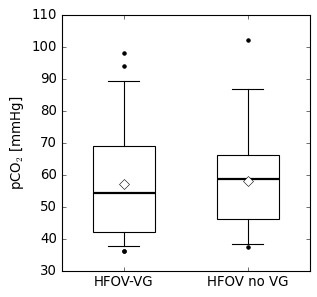

In [100]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([blood_gases_hfov_vg_combined['pCO2'].dropna(), blood_gases_hfov_novg_combined['pCO2'].dropna()] ,
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('pCO$_2$ [mmHg]',)
#ax.set_ylim(0, 100)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'pCO2_hfov_vg_novg.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

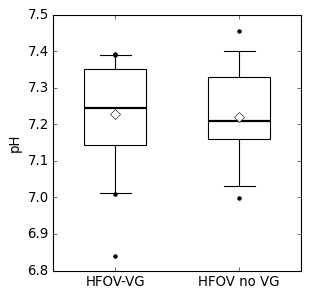

In [101]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([blood_gases_hfov_vg_combined['pH'].dropna(), blood_gases_hfov_novg_combined['pH'].dropna()] ,
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('pH',)
#ax.set_ylim(0, 100)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'pH_hfov_vg_novg.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

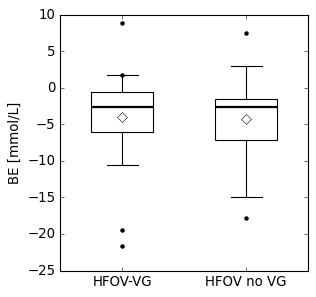

In [102]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([blood_gases_hfov_vg_combined['ABE'].dropna(), blood_gases_hfov_novg_combined['ABE'].dropna()] ,
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('BE [mmol/L]',)
#ax.set_ylim(0, 100)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'BE_hfov_vg_novg.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

In [103]:
sp.stats.ttest_ind(blood_gases_hfov_vg_combined['pCO2'].dropna(), blood_gases_hfov_novg_combined['pCO2'].dropna())

TtestResult(statistic=-0.18613144727830344, pvalue=0.8532170040115713, df=43.0)

In [104]:
sp.stats.ttest_ind(blood_gases_hfov_vg_combined['pH'].dropna(), blood_gases_hfov_novg_combined['pH'].dropna())

TtestResult(statistic=0.2139860060619337, pvalue=0.8315465300822307, df=44.0)

In [105]:
sp.stats.ttest_ind(blood_gases_hfov_vg_combined['ABE'].dropna(), blood_gases_hfov_novg_combined['ABE'].dropna())

TtestResult(statistic=0.11983898919340663, pvalue=0.9051821188112334, df=42.0)

#### B. Compare blood gases at the beginning and the end of the transport

In [106]:
blood_gases_hfov_combined = pd.concat(blood_gases_hfov)
blood_gases_hfov_combined.index.set_names(['recording', 'datetime'], inplace=True)

for column in blood_gases_hfov_combined:
    if column != 'Type':
       blood_gases_hfov_combined[column] = blood_gases_hfov_combined[column].astype('float') 

In [107]:
blood_gases_start = {}
blood_gases_end = {}

for recording in blood_gases_hfov_combined.index.levels[0]:
    blood_gases_start[recording] = blood_gases_hfov_combined.loc[recording].iloc[0]
    blood_gases_end[recording] = blood_gases_hfov_combined.loc[recording].iloc[-1]

blood_gases_start = DataFrame.from_dict(blood_gases_start).T
blood_gases_end = DataFrame.from_dict(blood_gases_end).T
blood_gases_start_end = pd.merge(blood_gases_start, blood_gases_end, left_index=True, right_index=True,
                                 suffixes=['_start', '_end'])
len(blood_gases_start_end)

50

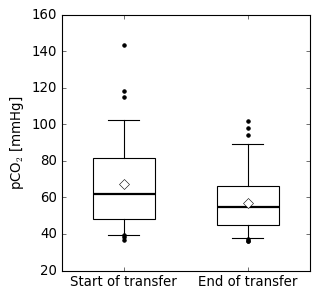

In [108]:
dpi = 200; filetype = 'jpg'

start_end_CO2 = blood_gases_start_end = blood_gases_start_end.dropna(how='any', subset=['pCO2_start', 'pCO2_end'],)

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([start_end_CO2['pCO2_start'].dropna(), start_end_CO2['pCO2_end'].dropna()] ,
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['Start of transfer', 'End of transfer'],)
ax.set_ylabel('pCO$_2$ [mmHg]',)
#ax.set_ylim(0, 100)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'pCO2_hfov_before_after.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

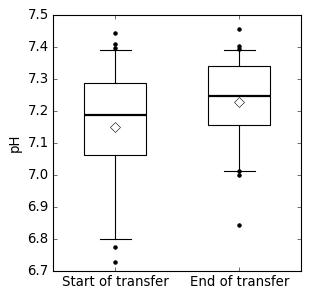

In [109]:
dpi = 200; filetype = 'jpg'

start_end_pH = blood_gases_start_end = blood_gases_start_end.dropna(how='any', subset=['pH_start', 'pH_end'],)

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([start_end_pH['pH_start'].dropna(), start_end_pH['pH_end'].dropna()],
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['Start of transfer', 'End of transfer'],)
ax.set_ylabel('pH',)
#ax.set_ylim(0, 100)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'pH_hfov_before_after.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

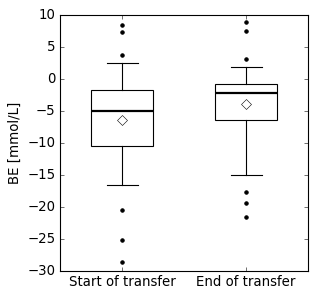

In [110]:
dpi = 200; filetype = 'jpg'

start_end_ABE = blood_gases_start_end = blood_gases_start_end.dropna(how='any', subset=['ABE_start', 'ABE_end'],)

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([start_end_ABE['ABE_start'].dropna(), start_end_ABE['ABE_end'].dropna()] ,
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['Start of transfer', 'End of transfer'],)
ax.set_ylabel('BE [mmol/L]',)
#ax.set_ylim(0, 100)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'BE_hfov_before_after.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

In [111]:
# Paired T-test
sp.stats.wilcoxon(start_end_CO2['pCO2_start'], start_end_CO2['pCO2_end'])

/Users/guszti/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


WilcoxonResult(statistic=221.0, pvalue=0.001385606123284086)

In [112]:
# Paired T-test
sp.stats.wilcoxon(start_end_pH['pH_start'], start_end_pH['pH_end'])

WilcoxonResult(statistic=171.0, pvalue=0.0002656962603588479)

#### C. Relationship between ventilator parameters and CO2 elimination

In [113]:
vent_mode_during_last_10min = {}

for recording in data_pars_hfov_combined.index.levels[0]:
    # Check if only HFO is used during the last 10 minutes of the recordings (0.5 Hz sampling rate)
    if (len(data_pars_hfov_combined.loc[recording][-300:]['Ventilator_mode'].dropna().unique()) == 1 and
        data_pars_hfov_combined.loc[recording][-300:]['Ventilator_mode'].dropna().unique()[0] == 'HFO'):
        # Check is VG is always on or off during the last 10 minutes
        if len(data_pars_hfov_combined.loc[recording][-300:]['VG_state'].dropna().unique()) == 1:
             vent_mode_during_last_10min[recording] = data_pars_hfov_combined.loc[recording][-300:]['VG_state'].dropna().unique()[0]

In [114]:
vent_mode_during_last_10min;

In [115]:
vent_data_for_gases = {}

for recording in vent_mode_during_last_10min:
    # VThf and DCO2 over the last 10 minutes of the recording
    vent_data_for_gases[recording] = (round(data_pars_hfov_only_combined.loc[recording][['VThf_emand_kg']][-300:].mean().values[0], 2),
                                      round(data_pars_hfov_only_combined.loc[recording][['DCO2_kg2']][-300:].median().values[0], 1))
    
    
vent_data_for_gases = DataFrame.from_dict(vent_data_for_gases).T

vent_data_for_gases['HFOV-VG'] = vent_mode_during_last_10min
vent_data_for_gases.columns = ['VThf_emand_kg_mean', 'DCO2_kg2_median', 'HFOV-VG']

In [116]:
vent_data_for_gases.head()

,VThf_emand_kg_mean,DCO2_kg2_median,HFOV-VG
AT000034,1.67,28.8,on
AT000048,1.49,21.4,off
AT000086,0.78,6.0,off
AT000122,1.46,21.7,off
AT000125,1.22,9.7,off


In [117]:
blood_gases_end.head()

,pH,pCO2,pO2,HCO3,ABE,Saturatio,FiO2,Type
AT000033,7.37,46.0,52.0,26.6,1.3,85.0,1.0,Capillaris
AT000034,7.01,94.0,25.0,23.7,-10.3,20.0,1.0,Capillaris
AT000048,7.07,67.0,57.0,19.4,-10.0,75.0,NaN,NaN
AT000086,7.17,71.0,52.0,25.9,-2.6,76.0,0.7,Capillaris
AT000122,7.202,55.0,47.8,18.4,-6.4,NaN,NaN,NaN


In [118]:
vent_data_for_gases = pd.merge(vent_data_for_gases, blood_gases_end, how='inner', left_index=True, right_index=True)
vent_data_for_gases = vent_data_for_gases.dropna(subset=['pCO2'])
vent_data_for_gases.head()

,VThf_emand_kg_mean,DCO2_kg2_median,HFOV-VG,pH,pCO2,pO2,HCO3,ABE,Saturatio,FiO2,Type
AT000034,1.67,28.8,on,7.01,94.0,25.0,23.7,-10.3,20.0,1.0,Capillaris
AT000048,1.49,21.4,off,7.07,67.0,57.0,19.4,-10.0,75.0,NaN,NaN
AT000086,0.78,6.0,off,7.17,71.0,52.0,25.9,-2.6,76.0,0.7,Capillaris
AT000122,1.46,21.7,off,7.202,55.0,47.8,18.4,-6.4,NaN,NaN,NaN
AT000125,1.22,9.7,off,7.032,102.0,31.0,17.7,-3.7,57.6,0.8,Capillaris


In [119]:
def corr_pearson(x, y):
    '''
    input: two numeric arrays of the same size

    returns: a tuple of 
    1. Pearson's correlation coefficient: r
    2. low and high 95% confidence intervals or r (two values)
    3. Coefficient of determination: r^2
    4. p-value of correlation
    '''
    assert len(x) == len(y)
    r, p = sp.stats.pearsonr(x, y)
    f = 0.5*np.log((1+r)/(1-r))
    se = 1/np.sqrt(len(x)-3)
    ucl = f + 1.96 * se
    lcl = f - 1.96 * se
    lcl = (np.exp(2*lcl) - 1) / (np.exp(2*lcl) + 1)
    ucl = (np.exp(2*ucl) - 1) / (np.exp(2*ucl) + 1)

    return r , lcl, ucl , r*r, p

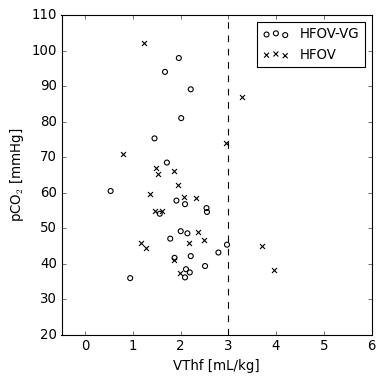

In [120]:
dpi=300; filetype = 'jpg'

fig,ax = plt.subplots(1,1, figsize=(5,5))
data_vg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'on']
data_novg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'off']
ax.scatter(data_vg['VThf_emand_kg_mean'], data_vg['pCO2'], marker='o', facecolors='none', color ='black')
ax.scatter(data_novg['VThf_emand_kg_mean'], data_novg['pCO2'], marker = 'x', color = 'black')
ax.set_xlim(-0.5, 6)
ax.set_ylim(20, 110)
ax.set_xlabel('VThf [mL/kg]')
ax.set_ylabel('pCO$_2$ [mmHg]')
ax.legend(['HFOV-VG', 'HFOV'], fontsize=12)
ax.vlines(3, 20, 110, color='black', linestyle='dashed')

fig.savefig(os.path.join(DIR_WRITE, f'VThf_CO2.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1);

[-4.605310751018745, 66.34995279677923]


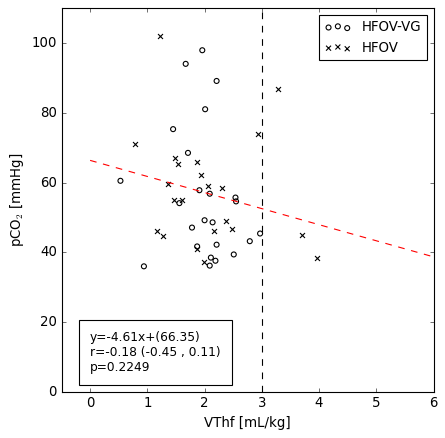

In [121]:
dpi=300; filetype = 'jpg'

fig,ax = plt.subplots(1,1, figsize=(6,6))
data_vg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'on']
data_novg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'off']
ax.scatter(data_vg['VThf_emand_kg_mean'], data_vg['pCO2'], marker='o', facecolors='none', color ='black')
ax.scatter(data_novg['VThf_emand_kg_mean'], data_novg['pCO2'], marker = 'x', color = 'black')
ax.set_xlim(-0.5, 6)
ax.set_ylim(0, 110)
ax.set_xlabel('VThf [mL/kg]')
ax.set_ylabel('pCO$_2$ [mmHg]')
ax.legend(['HFOV-VG', 'HFOV'], fontsize=12)
ax.vlines(3, 0, 110, color='black', linestyle='dashed')

# Polynomial Coefficients
coeffs = np.polyfit(vent_data_for_gases['VThf_emand_kg_mean'].astype('float'), vent_data_for_gases['pCO2'].astype('float'), deg = 1)
result = coeffs.tolist()
print(result)
# Fit a trendline
l = np.poly1d(coeffs)
ax.plot(x,l(x),'r--')

# Calculate pearson's correlation coefficient with confidence intervals, coefficiet of determination and p value
r , lcl, ucl , r2, p = corr_pearson(vent_data_for_gases['VThf_emand_kg_mean'].astype('float'), vent_data_for_gases['pCO2'].astype('float'))

# print the equation on the graph area 
text = 'y=%.2fx+(%.2f)\nr=%.2f (%.2f , %.2f)\np=%.4f' % (result[0], result[1], r, lcl, ucl, p)
ax.text(0, 6 ,  text, color = 'black', style='normal', fontsize = 11, 
         bbox={'facecolor':'white', 'edgecolor':'black', 'alpha':1, 'pad':10})

fig.savefig(os.path.join(DIR_WRITE, f'VThf_CO2_with_corr.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1);

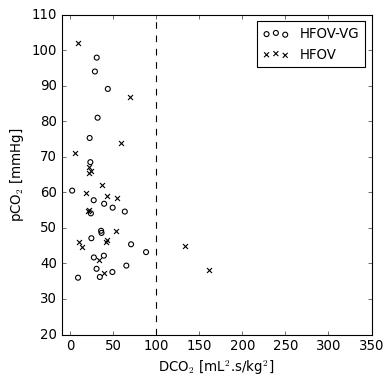

In [122]:
dpi=300; filetype = 'jpg'

fig,ax = plt.subplots(1,1, figsize=(5,5))
data_vg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'on']
data_novg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'off']
ax.scatter(data_vg['DCO2_kg2_median'], data_vg['pCO2'], marker='o', facecolors='none', color ='black')
ax.scatter(data_novg['DCO2_kg2_median'], data_novg['pCO2'], marker = 'x', color = 'black')
ax.set_xlim(-10, 350)
ax.set_ylim(20, 110)
ax.set_xlabel('DCO$_2$ [mL$^2$.s/kg$^2$]')
ax.set_ylabel('pCO$_2$ [mmHg]')
ax.legend(['HFOV-VG', 'HFOV'], fontsize=12)
ax.vlines(100, 20, 110, color='black', linestyle='dashed')

fig.savefig(os.path.join(DIR_WRITE, f'DCO2_CO2.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1);

[-0.14354090260148186, 62.816464473779654]


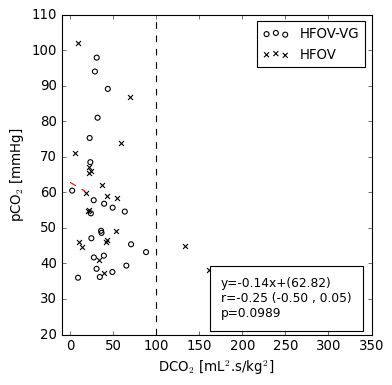

In [123]:
dpi=300; filetype = 'jpg'

fig,ax = plt.subplots(1,1, figsize=(5,5))
data_vg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'on']
data_novg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'off']
ax.scatter(data_vg['DCO2_kg2_median'], data_vg['pCO2'], marker='o', facecolors='none', color ='black')
ax.scatter(data_novg['DCO2_kg2_median'], data_novg['pCO2'], marker = 'x', color = 'black')
ax.set_xlim(-10, 350)
ax.set_ylim(20, 110)
ax.set_xlabel('DCO$_2$ [mL$^2$.s/kg$^2$]')
ax.set_ylabel('pCO$_2$ [mmHg]')
ax.legend(['HFOV-VG', 'HFOV'], fontsize=12)
ax.vlines(100, 20, 110, color='black', linestyle='dashed')

# Polynomial Coefficients
coeffs = np.polyfit(vent_data_for_gases['DCO2_kg2_median'].astype('float'), vent_data_for_gases['pCO2'].astype('float'), deg = 1)
result = coeffs.tolist()
print(result)
# Fit a trendline
l = np.poly1d(coeffs)
ax.plot(x,l(x),'r--')

# Calculate pearson's correlation coefficient with confidence intervals, coefficiet of determination and p value
r , lcl, ucl , r2, p = corr_pearson(vent_data_for_gases['DCO2_kg2_median'].astype('float'), vent_data_for_gases['pCO2'].astype('float'))

# print the equation on the graph area 
text = 'y=%.2fx+(%.2f)\nr=%.2f (%.2f , %.2f)\np=%.4f' % (result[0], result[1], r, lcl, ucl, p)
ax.text(175, 25 ,  text, color = 'black', style='normal', fontsize = 11, 
         bbox={'facecolor':'white', 'edgecolor':'black', 'alpha':1, 'pad':10})

fig.savefig(os.path.join(DIR_WRITE, f'DCO2_CO2_with_corr.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1);

### 10. Produce the figures of the manuscript

#### Figure 1

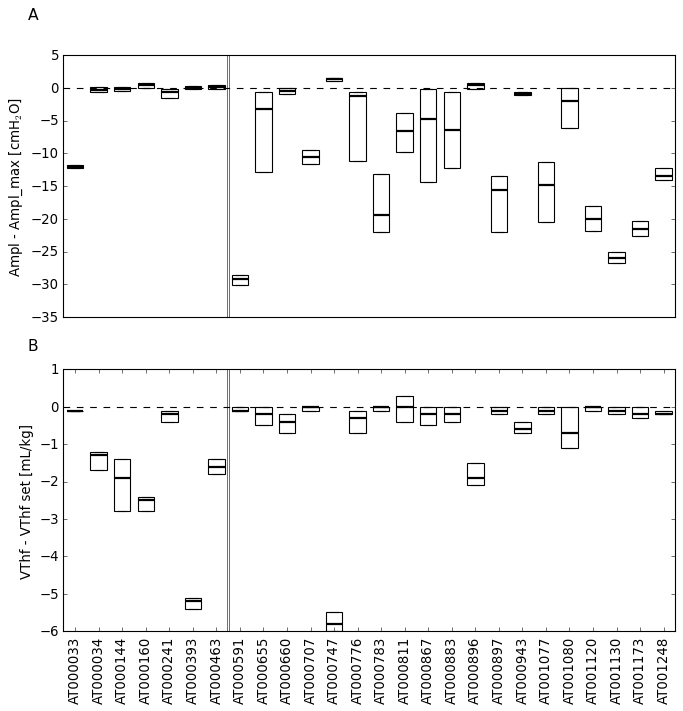

In [154]:
import matplotlib.ticker as ticker

dpi=300; filetype = 'pdf'

fig,ax = plt.subplots(2,1, figsize=(9,9))
fig.subplots_adjust(left=0.05, bottom=None, right=None, top=None, wspace=0.4, hspace=0.2)

# Figure 1A

data = data_pars_hfov_vg_only_combined['deltaP_diff'].groupby(level=0)
data_for_graph = [item[1].dropna() for item in data]
xticklabels = [item[0] for item in data]

ax[0].boxplot(data_for_graph, widths=0.7, whis = 0, patch_artist = True, showfliers = False, showmeans = False, medianprops=medianprops, 
    meanprops = meanprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, )
ax[0].hlines(0, *ax[0].get_xlim(), color='black', linestyle='--')
ax[0].xaxis.set_major_locator(ticker.NullLocator())
ax[0].set_ylabel('Ampl - Ampl_max [cmH$_2$O]')
ax[0].set_title('')
ax[0].axvline(x=7.45, color='black', linestyle='-', linewidth=0.5)
ax[0].axvline(x=7.55, color='black', linestyle='-', linewidth=0.5)

# Figure 1B

data = data_pars_hfov_vg_only_combined['VThf_diff'].groupby(level=0)
data_for_graph = [item[1].dropna() for item in data]
xticklabels = [item[0] for item in data]

ax[1].boxplot(data_for_graph, widths=0.7, whis = 0, patch_artist = True, showfliers = False, showmeans = False, medianprops=medianprops, 
    meanprops = meanprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, )
ax[1].hlines(0, *ax[1].get_xlim(), color='black', linestyle='--')
ax[1].set_xticklabels(xticklabels, rotation='vertical')
ax[1].set_ylabel('VThf - VThf set [mL/kg]')
ax[1].set_title('')
ax[1].axvline(x=7.45, color='black', linestyle='-', linewidth=0.5)
ax[1].axvline(x=7.55, color='black', linestyle='-', linewidth=0.5)

fig.text(0, 0.95, 'A', fontsize=14); fig.text(0, 0.49, 'B', fontsize=14)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_1.{filetype}'), dpi = dpi, format = filetype,
    bbox_inches='tight', pad_inches=0.1);

#### Figure 2

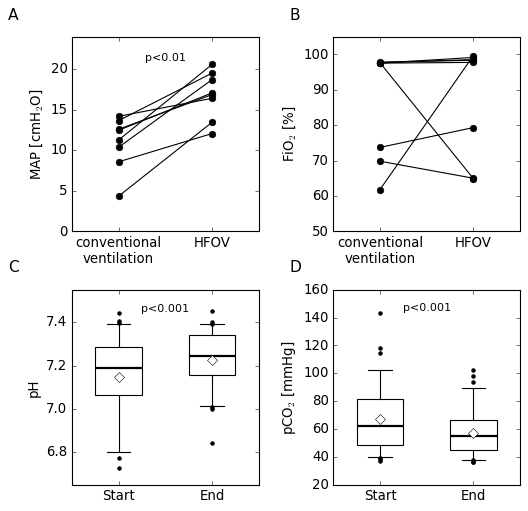

In [157]:
dpi=300; filetype = 'jpg'

# Define styling of boxplots
medianprops = {'color':'black', 'linewidth':2}; boxprops = {'color':'black', 'linestyle':'-'}
whiskerprops = {'color':'black', 'linestyle':'-'}; capprops = {'color':'black', 'linestyle':'-'}
flierprops = {'color':'black', 'marker': '.'}
meanprops =  {'marker':'D', 'markeredgecolor':'black', 'markerfacecolor':'white'}

fig,ax = plt.subplots(2,2, figsize=(8,7))
fig.subplots_adjust(left=0.2, bottom=None, right=None, top=None, wspace=0.4, hspace=0.3)

# Figure 2A

ax[0,0].plot([1, 2], [MAP_conventional_hfov['conventional'], MAP_conventional_hfov['hfov']], color = 'black', marker = 'o')
ax[0,0].set_xlim(0.5, 2.5)
ax[0,0].set_ylim(0, 24)
ax[0,0].set_xticks([1,2])
ax[0,0].set_xticklabels(['conventional\nventilation', 'HFOV'], size = 12)
ax[0,0].set_ylabel('MAP [cmH$_2$O]', size = 12)
ax[0,0].set_title('', size = 12)
ax[0,0].grid(False)

ax[0,0].text(1.5, 21, 'p<0.01', horizontalalignment ='center', fontsize=10)

# Figure 2B

ax[0,1].plot([1, 2], [FiO2_conventional_hfov['conventional'], FiO2_conventional_hfov['hfov']], color = 'black', marker = 'o')
ax[0,1].set_xlim(0.5, 2.5)
ax[0,1].set_ylim(50, 105)
ax[0,1].set_xticks([1,2])
ax[0,1].set_xticklabels(['conventional\nventilation', 'HFOV'], size = 12)
ax[0,1].set_ylabel('FiO$_2$ [%]', size = 12)
ax[0,1].set_title('', size = 12)
ax[0,1].grid(False)

# Figure 2C

ax[1,0].boxplot([start_end_pH['pH_start'].dropna(), start_end_pH['pH_end'].dropna()],
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax[1,0].tick_params(axis='both', which='major',)
ax[1,0].set_xticklabels(['Start', 'End'],)
ax[1,0].set_ylabel('pH',)
ax[1,0].set_ylim(6.65, 7.55)
ax[1,0].grid(False)

ax[1,0].text(1.5, 7.45, 'p<0.001', horizontalalignment ='center', fontsize=10)

# Figure 2D

ax[1,1].boxplot([start_end_CO2['pCO2_start'].dropna(), start_end_CO2['pCO2_end'].dropna()] ,
    widths = 0.5, whis = [5,95], patch_artist=True, showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax[1,1].tick_params(axis='both', which='major',)
ax[1,1].set_xticklabels(['Start', 'End'],)
ax[1,1].set_ylabel('pCO$_2$ [mmHg]',)
#[1,1]ax.set_ylim(0, 100)
ax[1,1].grid(False)

ax[1,1].text(1.5, 145, 'p<0.001', horizontalalignment ='center', fontsize=10)

fig.text(0.1, 0.93, 'A', fontsize=14); fig.text(0.54, 0.93, 'B', fontsize=14)
fig.text(0.1, 0.48, 'C', fontsize=14); fig.text(0.54, 0.48, 'D', fontsize=14)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_2.{filetype}'), dpi = dpi, format = filetype,
           bbox_inches='tight', pad_inches=0.1);

#### Figure 3

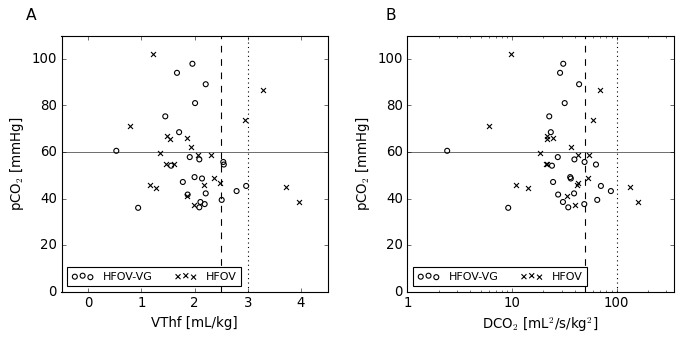

In [150]:
import matplotlib.ticker as ticker

dpi=300; filetype = 'jpg'

fig,ax = plt.subplots(1,2, figsize=(9,4))
fig.subplots_adjust(left=0.05, bottom=None, right=None, top=None, wspace=0.3, hspace=0.2)

# Figure 3A

data_vg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'on']
data_novg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'off']
ax[0].scatter(data_vg['VThf_emand_kg_mean'], data_vg['pCO2'], marker='o', facecolors='none', color ='black')
ax[0].scatter(data_novg['VThf_emand_kg_mean'], data_novg['pCO2'], marker = 'x', color = 'black')
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_ylim(0, 110)
ax[0].set_xlabel('VThf [mL/kg]')
ax[0].set_ylabel('pCO$_2$ [mmHg]')
ax[0].legend(['HFOV-VG', 'HFOV'], fontsize=10, loc=3, ncol=2)
ax[0].hlines(60, -0.5, 4.5, color='black', linestyle='-', linewidth=0.5)
ax[0].vlines(2.5, 0, 110, color='black', linestyle='dashed')
ax[0].vlines(3, 0, 110, color='black', linestyle='dotted')

# Figure 3B

data_vg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'on']
data_novg = vent_data_for_gases[vent_data_for_gases['HFOV-VG'] == 'off']
ax[1].scatter(data_vg['DCO2_kg2_median'], data_vg['pCO2'], marker='o', facecolors='none', color ='black')
ax[1].scatter(data_novg['DCO2_kg2_median'], data_novg['pCO2'], marker = 'x', color = 'black')
ax[1].set_xlim(1, 350)
ax[1].set_ylim(0, 110)
ax[1].set_xlabel('DCO$_2$ [mL$^2$/s/kg$^2$]')
ax[1].set_ylabel('pCO$_2$ [mmHg]')
ax[1].legend(['HFOV-VG', 'HFOV'], fontsize=10,loc=3, ncol=2)
ax[1].hlines(60, -10, 350, color='black', linestyle='-', linewidth=0.5)
ax[1].vlines(50, 0, 110, color='black', linestyle='dashed')
ax[1].vlines(100, 0, 110, color='black', linestyle='dotted')
ax[1].set_xscale('log')
ax[1].xaxis.set_major_formatter(ticker.ScalarFormatter()) 

fig.text(0, 0.95, 'A', fontsize=14); fig.text(0.5, 0.95, 'B', fontsize=14); 

fig.savefig(os.path.join(DIR_WRITE, f'Figure_3.{filetype}'), dpi = dpi, format = filetype,
    bbox_inches='tight', pad_inches=0.1);

#### Supplementary Figure 1

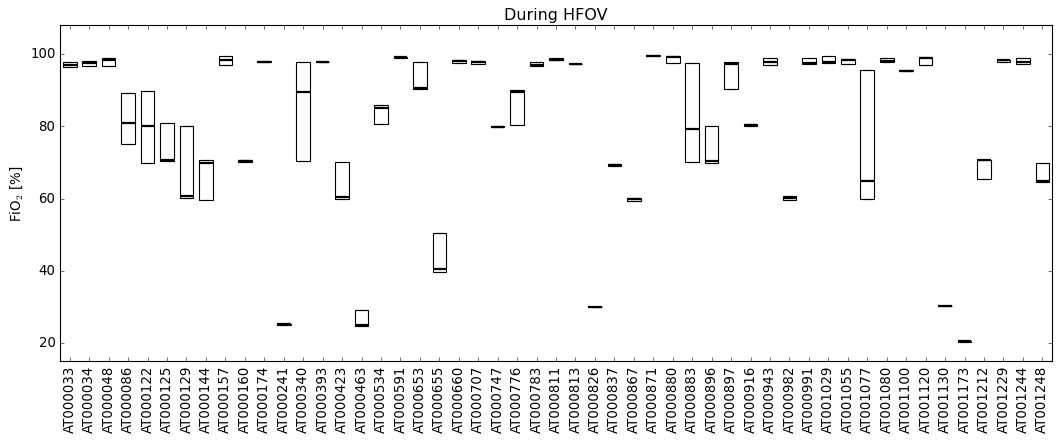

In [147]:
dpi=300; filetype = 'pdf'

fig, ax = plt.subplots(figsize = (16, 6))
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=None, hspace=None)

data = data_pars_hfov_only_combined['FiO2'].groupby(level=0)
data_for_graph = [item[1].dropna() for item in data]
xticklabels = [item[0] for item in data]

# Shows median and interquartile range
ax.boxplot(data_for_graph, widths=0.7, whis = 0, patch_artist = True, showfliers = False,
    showmeans = False, medianprops=medianprops, meanprops = meanprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, )

ax.set_ylim(15, 108)
ax.set_xticklabels(xticklabels, rotation='vertical')
ax.set_ylabel('FiO$_2$ [%]')
ax.set_title('During HFOV')

fig.savefig(os.path.join(DIR_WRITE, f'Supplementary_Figure_1.{filetype}'), dpi = dpi, format = filetype,
    bbox_inches='tight', pad_inches=0.1);